# BLACKALPHA CAPITAL - JUPYTER NOTEBOOK

In order to run this notebook, these files are needed to download (attached in repository):
- utils.py (backend file)
- target_prices_djia.xlsx
- F-F_Research_Data_Factors_daily.xlsx

(note that .env is not needed as we have already adjusted for public run)

# Import Dependencies

In [1]:
from utils import *  # backend file
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

import statsmodels.api as sm
from collections import OrderedDict
from scipy.stats import gaussian_kde, linregress
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import QuantileTransformer
from pypfopt import (
    BlackLittermanModel,
    DiscreteAllocation,
    EfficientFrontier,
    black_litterman,
    objective_functions,
    plotting,
)

np.random.seed(42)


In [2]:
fund = FundOverview()
fund.get_fund_overview()


# Instrument List 

In [3]:
tickers_dict = {
    "information_technology": ["AAPL", "MSFT", "CSCO", "CRM", "IBM", "INTC"],
    "health_care": ["JNJ", "MRK", "AMGN", "UNH"],
    "financials": ["AXP", "GS", "JPM", "TRV", "V"],
    "consumer_staples": ["KO", "PG", "WMT"],
    "consumer_discretionary": ["MCD", "NKE", "HD"],
    "industrials": ["BA", "CAT", "HON", "MMM"],
    "communication_services": ["DIS", "VZ"],
    "energy": ["CVX"],
    "materials": ["SHW"],
}


# Historical Data

In [4]:
df = get_historical_data(tickers_dict, start_date="2018-10-01", end_date="2024-10-01")
df



🔹 Sector: information_technology
  → Fetching AAPL ...
  → Fetching MSFT ...
  → Fetching CSCO ...
  → Fetching CRM ...
  → Fetching IBM ...
  → Fetching INTC ...

🔹 Sector: health_care
  → Fetching JNJ ...
  → Fetching MRK ...
  → Fetching AMGN ...
  → Fetching UNH ...

🔹 Sector: financials
  → Fetching AXP ...
  → Fetching GS ...
  → Fetching JPM ...
  → Fetching TRV ...
  → Fetching V ...

🔹 Sector: consumer_staples
  → Fetching KO ...
  → Fetching PG ...
  → Fetching WMT ...

🔹 Sector: consumer_discretionary
  → Fetching MCD ...
  → Fetching NKE ...
  → Fetching HD ...

🔹 Sector: industrials
  → Fetching BA ...
  → Fetching CAT ...
  → Fetching HON ...
  → Fetching MMM ...

🔹 Sector: communication_services
  → Fetching DIS ...
  → Fetching VZ ...

🔹 Sector: energy
  → Fetching CVX ...

🔹 Sector: materials
  → Fetching SHW ...

✅ Data download complete!


,AAPL,MSFT,CSCO,CRM,IBM,INTC,JNJ,MRK,AMGN,UNH,...,NKE,HD,BA,CAT,HON,MMM,DIS,VZ,CVX,SHW
Date,,,,,,,,,,,,,,,,,,,,,
2018-10-01,53.8336,107.7048,39.3810,158.1959,106.4697,39.7259,114.0251,55.0303,165.7806,240.8093,...,76.8646,173.7582,369.7625,129.8869,130.7336,136.6939,112.0841,36.2755,90.5814,142.7918
2018-10-02,54.3122,107.2763,39.4938,155.6230,106.9916,41.1370,114.6699,55.1995,166.3895,242.1785,...,75.3266,171.3728,373.7088,132.0533,130.4116,138.9615,113.4534,36.6663,90.8363,141.8545
2018-10-03,54.9730,107.2949,39.5985,157.4438,106.6228,41.7014,113.4863,54.9072,165.7726,242.4201,...,75.0809,170.5274,379.4445,134.9533,129.9010,138.9937,112.7302,36.5787,91.2513,138.1706
2018-10-04,54.0066,105.0777,39.2497,153.2876,105.2937,41.1626,113.7475,54.7918,163.0244,240.1114,...,72.9695,166.4345,377.2102,133.6995,129.3748,137.7568,111.9781,37.0706,90.9892,137.2551
2018-10-05,53.1301,104.4628,39.0469,153.4558,103.7071,40.2219,113.5435,54.6456,163.4651,240.8988,...,72.9149,164.3672,373.8055,130.7654,128.8720,137.3381,110.6763,37.0167,91.2659,138.0894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-24,226.0975,425.1762,50.8113,268.8129,213.7201,22.8100,156.6880,110.8544,317.9454,562.9804,...,85.0187,388.8663,155.8100,378.8276,188.4072,133.9648,92.8806,41.1410,139.4945,377.4949
2024-09-25,225.1031,428.0888,50.9371,272.4409,213.9716,23.5400,154.5895,110.6326,300.5935,564.0767,...,85.5436,385.2460,152.2200,371.2890,189.7932,133.3595,93.1086,41.0397,136.2023,377.1190
2024-09-26,226.2467,427.2963,51.1306,274.1009,216.0994,23.9200,155.3500,109.0511,306.5889,562.6085,...,86.8948,385.0228,154.5800,383.7651,190.0226,136.1322,94.3776,41.1042,134.3291,379.8397


# Historical Market Cap

In [5]:
caps = get_caps(tickers_dict, start_date="2018-10-01", end_date="2024-10-01")
caps



🔹 Sector: information_technology
  → Fetching market cap for AAPL ...
  → Fetching market cap for MSFT ...
  → Fetching market cap for CSCO ...
  → Fetching market cap for CRM ...
  → Fetching market cap for IBM ...
  → Fetching market cap for INTC ...

🔹 Sector: health_care
  → Fetching market cap for JNJ ...
  → Fetching market cap for MRK ...
  → Fetching market cap for AMGN ...
  → Fetching market cap for UNH ...

🔹 Sector: financials
  → Fetching market cap for AXP ...
  → Fetching market cap for GS ...
  → Fetching market cap for JPM ...
  → Fetching market cap for TRV ...
  → Fetching market cap for V ...

🔹 Sector: consumer_staples
  → Fetching market cap for KO ...
  → Fetching market cap for PG ...
  → Fetching market cap for WMT ...

🔹 Sector: consumer_discretionary
  → Fetching market cap for MCD ...
  → Fetching market cap for NKE ...
  → Fetching market cap for HD ...

🔹 Sector: industrials
  → Fetching market cap for BA ...
  → Fetching market cap for CAT ...
  → Fetchi

,AAPL,MSFT,CSCO,CRM,IBM,INTC,JNJ,MRK,AMGN,UNH,...,NKE,HD,BA,CAT,HON,MMM,DIS,VZ,CVX,SHW
Date,,,,,,,,,,,,,,,,,,,,,
2018-10-01 00:00:00-04:00,"795,464,939,830.5931","800,503,058,145.4948","155,597,921,385.2596","150,602,504,028.3203","99,521,023,185.5531","189,492,355,041.5039","274,720,006,352.0827","136,586,416,706.7755","89,269,661,860.1369","218,134,401,524.6616",...,"91,416,116,334.2435","172,978,247,329.1210","281,054,832,961.1320","60,784,398,433.6081","83,001,068,890.0458","72,615,211,994.1980","200,102,545,912.7120","152,953,012,439.4455","181,104,182,917.6602","35,397,166,963.5249"
2018-10-02 00:00:00-04:00,"802,535,542,886.9819","797,318,020,757.6187","156,043,682,576.4397","148,153,053,466.7969","100,008,843,826.3553","196,223,385,772.7051","276,273,625,975.7715","137,006,490,764.7540","89,597,535,589.0123","219,374,621,978.9975",...,"89,586,940,531.3147","170,603,547,767.8104","284,054,343,000.4105","61,798,256,633.9816","82,796,631,256.5249","73,819,806,292.4949","202,547,034,467.8784","154,600,713,105.9442","181,613,814,293.3604","35,164,800,838.0808"
2018-10-03 00:00:00-04:00,"812,301,123,563.6216","797,456,379,838.7207","156,457,566,001.9615","149,886,513,916.0156","99,664,108,872.6044","198,915,899,963.3789","273,422,036,114.0645","136,280,879,035.7370","89,265,339,948.0130","219,593,493,355.7629",...,"89,294,702,498.2529","169,762,005,161.1667","288,414,012,889.4546","63,155,401,746.8627","82,472,474,138.8051","73,836,933,955.5568","201,255,944,498.8271","154,231,383,416.6192","182,443,700,405.1522","34,251,601,322.0512"
2018-10-04 00:00:00-04:00,"798,020,070,146.3356","780,976,792,597.7279","155,079,240,747.1503","145,929,763,916.0156","98,421,743,718.3224","196,345,827,369.6899","274,051,399,021.4541","135,994,438,652.6590","87,785,495,873.7568","217,502,141,759.1180",...,"86,783,616,779.4467","165,687,495,866.5343","286,715,744,166.9606","62,568,634,910.5756","82,138,377,533.2402","73,179,857,465.6737","199,913,164,075.8987","156,305,272,079.7230","181,919,516,849.4934","34,024,655,597.6711"
2018-10-05 00:00:00-04:00,"785,069,341,692.2493","776,406,746,785.2960","154,277,880,442.4110","146,089,888,061.5234","96,938,656,007.8992","191,858,394,699.0967","273,559,694,889.5381","135,631,599,649.5744","88,022,798,428.9807","218,215,467,557.1674",...,"86,718,703,223.7438","163,629,422,913.3984","284,127,898,381.5454","61,195,515,823.7526","81,819,170,784.2229","72,957,424,809.6958","197,589,218,476.4139","156,077,951,441.3104","182,472,804,765.0695","34,231,470,565.2735"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-24 00:00:00-04:00,"3,340,896,977,468.6279","3,160,070,378,282.1543","200,760,425,596.8609","255,909,906,738.2812","199,771,709,207.8456","108,803,697,452.5452","377,507,529,182.3975","275,143,025,908.6152","171,207,470,948.8085","509,969,395,611.4514",...,"101,113,860,383.5330","387,120,839,877.9129","118,430,473,013.3782","177,283,604,385.2754","119,617,328,351.6791","71,165,472,445.5553","165,818,712,766.8744","173,468,084,828.3897","278,898,905,019.6023","93,578,537,784.1885"
2024-09-25 00:00:00-04:00,"3,326,203,146,215.4238","3,181,717,904,020.4722","201,257,372,079.8499","259,363,782,958.9844","200,006,790,776.2246","112,285,804,367.0654","372,451,818,107.3053","274,592,546,819.8585","161,863,809,166.5246","510,962,423,410.1465",...,"101,738,170,180.3717","383,516,850,118.3127","115,701,733,066.8109","173,755,662,623.1571","120,497,263,654.2585","70,843,921,444.1345","166,225,780,198.9084","173,040,787,009.0966","272,316,560,474.7915","93,485,343,198.4144"
2024-09-26 00:00:00-04:00,"3,343,100,939,421.9819","3,175,827,436,256.1792","202,021,865,710.9248","260,944,048,339.8438","201,995,713,204.6774","114,098,400,363.9221","374,283,898,512.0930","270,667,405,574.7061","165,092,178,924.2549","509,632,525,817.0386",...,"103,345,175,391.8292","383,294,646,413.4393","117,495,558,835.2164","179,594,239,358.9215","120,642,945,933.2183","72,316,811,303.0966

# Market Cap as of 10/2024

In [6]:
caps_dict = caps.iloc[-1].to_dict()
caps_dict


{'AAPL': 3423622323000.229,
 'MSFT': 3168390749056.03,
 'CSCO': 203436213594.54138,
 'CRM': 259004168212.89062,
 'IBM': 199871193126.02563,
 'INTC': 111904195632.93457,
 'JNJ': 375837720331.87354,
 'MRK': 271792280335.95184,
 'AMGN': 166701212018.13593,
 'UNH': 518383400151.5332,
 'AXP': 184343854055.8234,
 'GS': 144810250210.37357,
 'JPM': 558693119169.329,
 'TRV': 51373857557.07617,
 'V': 459867009267.26227,
 'KO': 297994943861.23914,
 'PG': 391999888905.505,
 'WMT': 637376268489.3799,
 'MCD': 210648141271.80328,
 'NKE': 102200613480.12006,
 'HD': 391507403500.4927,
 'BA': 115564909851.53998,
 'CAT': 179667732492.49744,
 'HON': 120456449753.39026,
 'MMM': 70895782678.52637,
 'DIS': 170243388377.40222,
 'VZ': 174439131427.28918,
 'CVX': 278558438922.4569,
 'SHW': 93605522530.30884}

# Risk Free Rate

In [7]:
ticker = "^IRX"
start_date = "2018-10-01"
end_date = "2024-10-01"
rf = yf.download(ticker, start=start_date, end=end_date)
rf = rf[["Close"]]
rf = rf.rename(columns={"Close": "rf"})
rf


[*********************100%***********************]  1 of 1 completed


Price,rf
Ticker,^IRX
Date,
2018-10-01,2.1550
2018-10-02,2.1750
2018-10-03,2.1700
2018-10-04,2.1700
2018-10-05,2.1650
...,...
2024-09-24,4.4950
2024-09-25,4.4870


In [8]:
rolling_rf = rf.rolling(window=252).mean()
rolling_rf.tail


<bound method NDFrame.tail of Price          rf
Ticker       ^IRX
Date             
2018-10-01    NaN
2018-10-02    NaN
2018-10-03    NaN
2018-10-04    NaN
2018-10-05    NaN
...           ...
2024-09-24 5.1910
2024-09-25 5.1877
2024-09-26 5.1843
2024-09-27 5.1810
2024-09-30 5.1778

[1509 rows x 1 columns]>

# Asset Allocation

## VCV Estimation

### Price Matrix

In [9]:
selected_tickers = [t for sector in tickers_dict.values() for t in sector]

filtered_df = df[selected_tickers]
filtered_df


,AAPL,MSFT,CSCO,CRM,IBM,INTC,JNJ,MRK,AMGN,UNH,...,NKE,HD,BA,CAT,HON,MMM,DIS,VZ,CVX,SHW
Date,,,,,,,,,,,,,,,,,,,,,
2018-10-01,53.8336,107.7048,39.3810,158.1959,106.4697,39.7259,114.0251,55.0303,165.7806,240.8093,...,76.8646,173.7582,369.7625,129.8869,130.7336,136.6939,112.0841,36.2755,90.5814,142.7918
2018-10-02,54.3122,107.2763,39.4938,155.6230,106.9916,41.1370,114.6699,55.1995,166.3895,242.1785,...,75.3266,171.3728,373.7088,132.0533,130.4116,138.9615,113.4534,36.6663,90.8363,141.8545
2018-10-03,54.9730,107.2949,39.5985,157.4438,106.6228,41.7014,113.4863,54.9072,165.7726,242.4201,...,75.0809,170.5274,379.4445,134.9533,129.9010,138.9937,112.7302,36.5787,91.2513,138.1706
2018-10-04,54.0066,105.0777,39.2497,153.2876,105.2937,41.1626,113.7475,54.7918,163.0244,240.1114,...,72.9695,166.4345,377.2102,133.6995,129.3748,137.7568,111.9781,37.0706,90.9892,137.2551
2018-10-05,53.1301,104.4628,39.0469,153.4558,103.7071,40.2219,113.5435,54.6456,163.4651,240.8988,...,72.9149,164.3672,373.8055,130.7654,128.8720,137.3381,110.6763,37.0167,91.2659,138.0894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-24,226.0975,425.1762,50.8113,268.8129,213.7201,22.8100,156.6880,110.8544,317.9454,562.9804,...,85.0187,388.8663,155.8100,378.8276,188.4072,133.9648,92.8806,41.1410,139.4945,377.4949
2024-09-25,225.1031,428.0888,50.9371,272.4409,213.9716,23.5400,154.5895,110.6326,300.5935,564.0767,...,85.5436,385.2460,152.2200,371.2890,189.7932,133.3595,93.1086,41.0397,136.2023,377.1190
2024-09-26,226.2467,427.2963,51.1306,274.1009,216.0994,23.9200,155.3500,109.0511,306.5889,562.6085,...,86.8948,385.0228,154.5800,383.7651,190.0226,136.1322,94.3776,41.1042,134.3291,379.8397


### Log Returns

In [10]:
dataprocessor = DataProcessor()

log_returns = dataprocessor.return_from_prices(filtered_df, log_returns=True)
log_returns.dropna(inplace=True)
log_returns


,AAPL,MSFT,CSCO,CRM,IBM,INTC,JNJ,MRK,AMGN,UNH,...,NKE,HD,BA,CAT,HON,MMM,DIS,VZ,CVX,SHW
Date,,,,,,,,,,,,,,,,,,,,,
2018-10-02,0.0088,-0.0040,0.0029,-0.0164,0.0049,0.0349,0.0056,0.0031,0.0037,0.0057,...,-0.0202,-0.0138,0.0106,0.0165,-0.0025,0.0165,0.0121,0.0107,0.0028,-0.0066
2018-10-03,0.0121,0.0002,0.0026,0.0116,-0.0035,0.0136,-0.0104,-0.0053,-0.0037,0.0010,...,-0.0033,-0.0049,0.0152,0.0217,-0.0039,0.0002,-0.0064,-0.0024,0.0046,-0.0263
2018-10-04,-0.0177,-0.0209,-0.0088,-0.0268,-0.0125,-0.0130,0.0023,-0.0021,-0.0167,-0.0096,...,-0.0285,-0.0243,-0.0059,-0.0093,-0.0041,-0.0089,-0.0067,0.0134,-0.0029,-0.0066
2018-10-05,-0.0164,-0.0059,-0.0052,0.0011,-0.0152,-0.0231,-0.0018,-0.0027,0.0027,0.0033,...,-0.0007,-0.0125,-0.0091,-0.0222,-0.0039,-0.0030,-0.0117,-0.0015,0.0030,0.0061
2018-10-08,-0.0023,-0.0115,-0.0128,-0.0423,-0.0043,0.0000,0.0021,0.0060,0.0076,-0.0007,...,0.0014,0.0103,-0.0018,0.0003,0.0048,0.0055,0.0107,0.0015,-0.0039,0.0014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-24,0.0040,-0.0101,0.0063,0.0233,0.0021,0.0110,-0.0027,-0.0058,-0.0141,0.0031,...,0.0145,0.0220,-0.0031,0.0390,0.0073,0.0116,0.0077,0.0090,-0.0006,-0.0008
2024-09-25,-0.0044,0.0068,0.0025,0.0134,0.0012,0.0315,-0.0135,-0.0020,-0.0561,0.0019,...,0.0062,-0.0094,-0.0233,-0.0201,0.0073,-0.0045,0.0025,-0.0025,-0.0239,-0.0010
2024-09-26,0.0051,-0.0019,0.0038,0.0061,0.0099,0.0160,0.0049,-0.0144,0.0197,-0.0026,...,0.0157,-0.0006,0.0154,0.0331,0.0012,0.0206,0.0135,0.0016,-0.0138,0.0072


### Finding the Optimal Shrinkage Intensity (Delta)

#### Quantile Scaling

In [11]:
scaler = QuantileTransformer(output_distribution="uniform")
scaled_df = pd.DataFrame(
    scaler.fit_transform(filtered_df), columns=filtered_df.columns, index=filtered_df.index
)
scaled_df


,AAPL,MSFT,CSCO,CRM,IBM,INTC,JNJ,MRK,AMGN,UNH,...,NKE,HD,BA,CAT,HON,MMM,DIS,VZ,CVX,SHW
Date,,,,,,,,,,,,,,,,,,,,,
2018-10-01,0.1645,0.0741,0.2631,0.2513,0.4355,0.3514,0.1341,0.0099,0.1622,0.1828,...,0.1309,0.1273,0.9540,0.3054,0.1512,0.9142,0.4908,0.2852,0.4202,0.1151
2018-10-02,0.1682,0.0720,0.2694,0.2135,0.4384,0.4125,0.1500,0.0113,0.1664,0.1906,...,0.1002,0.1181,0.9678,0.3205,0.1492,0.9407,0.5106,0.3075,0.4304,0.1119
2018-10-03,0.1711,0.0721,0.2804,0.2393,0.4362,0.4404,0.1248,0.0080,0.1621,0.1918,...,0.0956,0.1158,0.9777,0.3294,0.1447,0.9410,0.5025,0.3001,0.4424,0.0962
2018-10-04,0.1664,0.0662,0.2497,0.1778,0.4224,0.4140,0.1286,0.0070,0.1523,0.1782,...,0.0747,0.1037,0.9750,0.3256,0.1400,0.9229,0.4874,0.3253,0.4360,0.0901
2018-10-05,0.1596,0.0624,0.2326,0.1803,0.3971,0.3674,0.1263,0.0056,0.1547,0.1840,...,0.0726,0.0961,0.9681,0.3125,0.1363,0.9192,0.4563,0.3224,0.4432,0.0950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-24,0.9900,0.9724,0.9417,0.9053,0.9980,0.0238,0.8889,0.8939,0.9882,0.9800,...,0.2672,0.9991,0.1089,0.9980,0.8665,0.8879,0.1762,0.6550,0.7238,0.9976
2024-09-25,0.9849,0.9784,0.9461,0.9193,0.9990,0.0251,0.8590,0.8926,0.9580,0.9821,...,0.2728,0.9980,0.0977,0.9971,0.8899,0.8835,0.1810,0.6459,0.6537,0.9969
2024-09-26,0.9909,0.9770,0.9509,0.9266,1.0000,0.0271,0.8718,0.8800,0.9644,0.9789,...,0.2951,0.9979,0.1051,0.9990,0.8944,0.9058,0.2022,0.6510,0.6306,1.0000


#### Train-Test Split

In [12]:
base_X_train = scaled_df.loc[:"2023-01-01"]
base_X_test = scaled_df.loc["2023-01-01":]


#### Feature Transformation

In [13]:
np.random.seed(42)
num_features = filtered_df.shape[1]
colorMatrix = VcvEstimation().color_matrix(num_features)
X_train = np.dot(base_X_train, colorMatrix)
X_test = np.dot(base_X_test, colorMatrix)


#### Optimal Shrinkage (Delta)

In [14]:
shrinkageFactor = VcvEstimation().shrinkage_factor()
negative_logliks = VcvEstimation().negative_log_likelihood(shrinkageFactor, X_train, X_test)
realCovariance = VcvEstimation().real_covariance(colorMatrix)
empiricalCovariance = empirical_covariance(X_train)
logRealLikelihood = VcvEstimation().log_real_likelihood(empiricalCovariance, realCovariance)

tunedParameters = [{"shrinkage": shrinkageFactor}]
cv, optimal_shrinkage_coef = VcvEstimation().get_optimal_shrinkage_coefficient(
    tunedParameters, X_train
)
print(f"Optimal shrinkage coefficient: {optimal_shrinkage_coef}")


Optimal shrinkage coefficient: 0.16819243248808696


In [15]:
cv


GridSearchCV(estimator=ShrunkCovariance(),
             param_grid=[{'shrinkage': array([0.01      , 0.01160155, 0.0134596 , 0.01561523, 0.01811609,
       0.02101748, 0.02438354, 0.02828869, 0.03281928, 0.03807546,
       0.04417345, 0.05124806, 0.05945571, 0.06897785, 0.08002502,
       0.09284145, 0.10771051, 0.12496091, 0.14497407, 0.16819243,
       0.19512934, 0.22638034, 0.26263635, 0.30469896, 0.35349811,
       0.41011271, 0.47579443, 0.55199543, 0.64040043, 0.74296395,
       0.86195357, 1.        ])}])

#### Cross-Validation Plotting

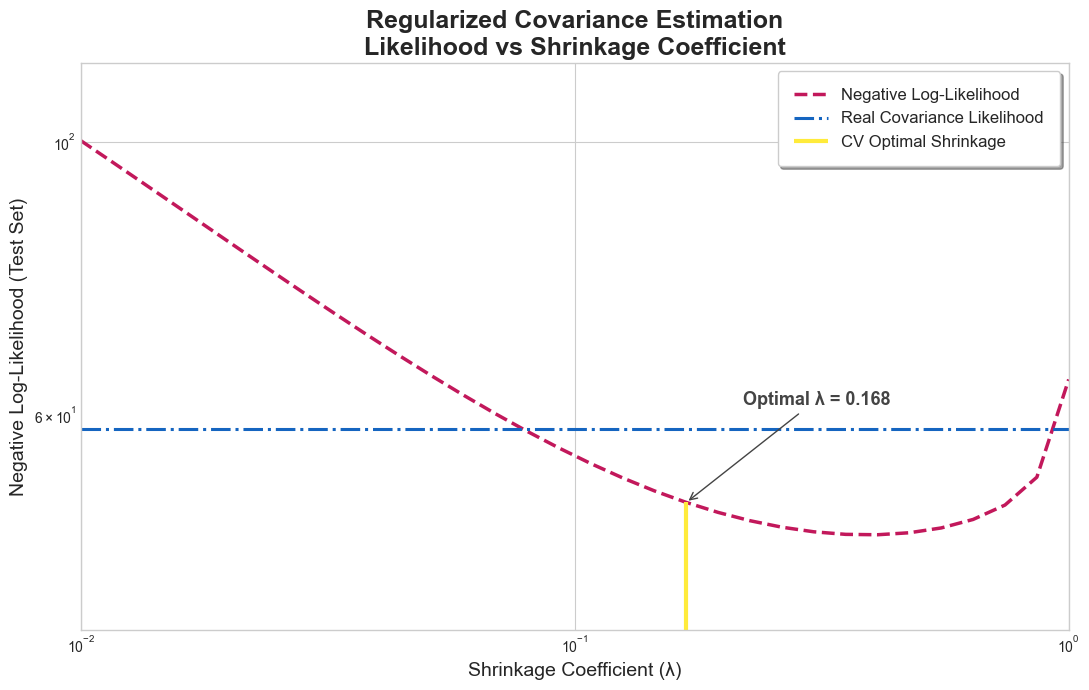

In [16]:
vcv = VcvEstimation()
vcv.plot_shrinkage_intensity(shrinkageFactor, negative_logliks, logRealLikelihood, cv, X_test)


### Estimated VCV Matrix Using Ledoit-Wolf Shrinkage Method (with Backtested Optimal Delta)

In [17]:
cov_estimator = CovarianceShrinkage(log_returns, returns_data=True, delta=optimal_shrinkage_coef)
cov_matrix = cov_estimator.ledoit_wolf()
cov_matrix


,AAPL,MSFT,CSCO,CRM,IBM,INTC,JNJ,MRK,AMGN,UNH,...,NKE,HD,BA,CAT,HON,MMM,DIS,VZ,CVX,SHW
AAPL,0.1007,0.0686,0.0481,0.0665,0.0344,0.0649,0.0225,0.0222,0.0317,0.0383,...,0.0524,0.0482,0.0633,0.0401,0.0400,0.0352,0.0444,0.0160,0.0366,0.0425
MSFT,0.0686,0.0885,0.0467,0.0750,0.0342,0.0654,0.0220,0.0231,0.0307,0.0388,...,0.0492,0.0478,0.0553,0.0366,0.0383,0.0313,0.0453,0.0151,0.0351,0.0422
CSCO,0.0481,0.0467,0.0770,0.0477,0.0397,0.0541,0.0252,0.0226,0.0303,0.0340,...,0.0419,0.0398,0.0507,0.0420,0.0394,0.0374,0.0414,0.0198,0.0386,0.0361
CRM,0.0665,0.0750,0.0477,0.1497,0.0346,0.0650,0.0181,0.0217,0.0278,0.0353,...,0.0529,0.0503,0.0654,0.0415,0.0372,0.0328,0.0499,0.0142,0.0371,0.0465
IBM,0.0344,0.0342,0.0397,0.0346,0.0697,0.0455,0.0225,0.0211,0.0263,0.0308,...,0.0333,0.0357,0.0549,0.0443,0.0374,0.0375,0.0347,0.0209,0.0420,0.0325
INTC,0.0649,0.0654,0.0541,0.0650,0.0455,0.1710,0.0216,0.0197,0.0352,0.0342,...,0.0504,0.0517,0.0789,0.0517,0.0468,0.0433,0.0519,0.0200,0.0479,0.0435
JNJ,0.0225,0.0220,0.0252,0.0181,0.0225,0.0216,0.0405,0.0233,0.0259,0.0275,...,0.0201,0.0212,0.0253,0.0206,0.0224,0.0234,0.0182,0.0161,0.0233,0.0208
MRK,0.0222,0.0231,0.0226,0.0217,0.0211,0.0197,0.0233,0.0532,0.0270,0.0281,...,0.0208,0.0203,0.0233,0.0208,0.0217,0.0167,0.0155,0.0166,0.0264,0.0217
AMGN,0.0317,0.0307,0.0303,0.0278,0.0263,0.0352,0.0259,0.0270,0.0653,0.0313,...,0.0223,0.0285,0.0251,0.0288,0.0260,0.0263,0.0223,0.0177,0.0253,0.0264
UNH,0.0383,0.0388,0.0340,0.0353,0.0308,0.0342,0.0275,0.0281,0.0313,0.0837,...,0.0324,0.0379,0.0487,0.0318,0.0359,0.0283,0.0295,0.0200,0.0432,0.0352


## Black-Litterman Optimization

### Target Prices for Viewdict (from Analyst Report)

In [18]:
target_df = pd.read_excel("target_prices_djia.xlsx", sheet_name="Tickers", index_col=0)
target_series = target_df["Target price"]
target_series


Ticker
AAPL    280
MSFT    530
CSCO     75
CRM     250
IBM     304
INTC     42
JNJ     180
MRK      80
AMGN    280
UNH     340
AXP     360
GS      770
JPM     302
TRV     276
V       345
KO       67
PG      144
WMT     103
MCD     315
NKE      66
HD      355
BA      211
CAT     596
HON     201
MMM     180
DIS     115
VZ       35
CVX     170
SHW     330
Name: Target price, dtype: int64

### Market Price

In [19]:
start_date = "2018-10-01"
end_date = "2024-10-01"

market_prices = yf.download("^DJI", start=start_date, end=end_date, auto_adjust=False)["Adj Close"]
market_prices.head()


[*********************100%***********************]  1 of 1 completed


Ticker,^DJI
Date,
2018-10-01,"26,651.2109"
2018-10-02,"26,773.9395"
2018-10-03,"26,828.3906"
2018-10-04,"26,627.4805"
2018-10-05,"26,447.0508"


### Market Risk Aversion

In [20]:
S = cov_matrix
risk_free = rolling_rf.iloc[-1].values.item() / 100
delta = black_litterman.market_implied_risk_aversion(market_prices, risk_free_rate=risk_free)
delta


np.float64(1.1369754387296733)

<Axes: >

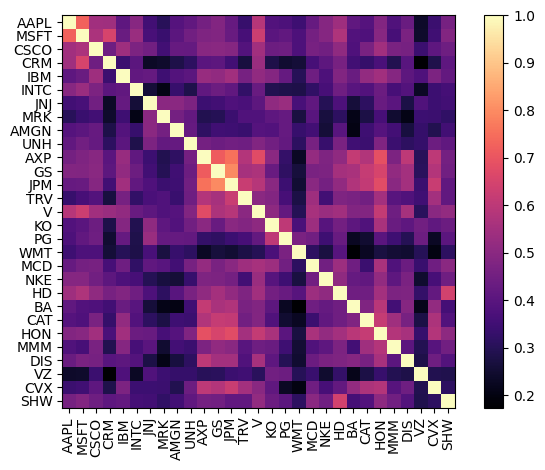

In [21]:
plt.style.use("default")
plt.rcParams["image.cmap"] = "magma"  # 'plasma', 'inferno', 'magma'
plotting.plot_covariance(S, plot_correlation=True, cmap="plasma")


### Market-Implied Prior

In [22]:
market_prior = black_litterman.market_implied_prior_returns(caps_dict, delta, S, risk_free)


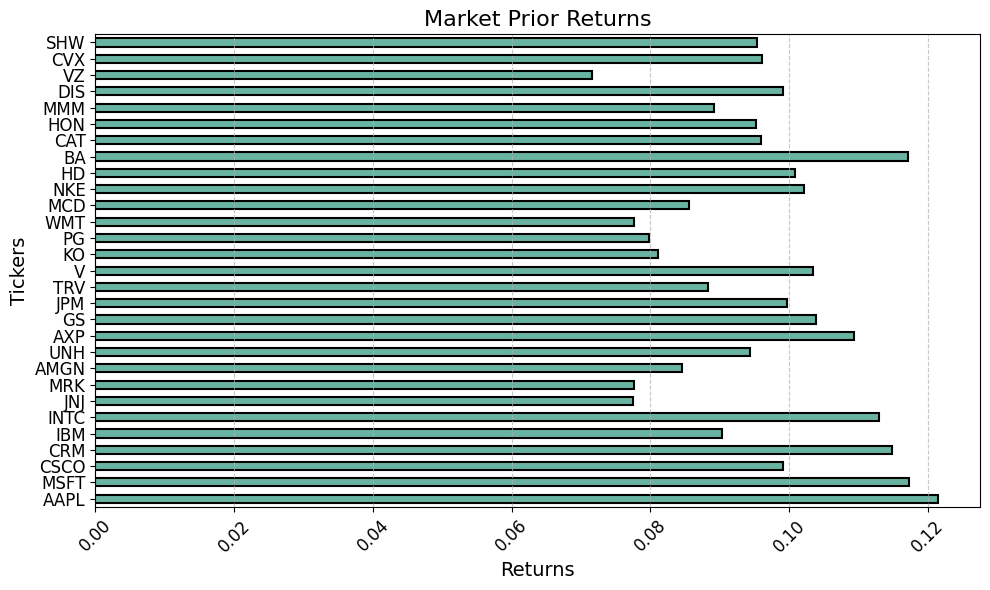

In [23]:
BlackLitterman().plot_market_prior(market_prior=market_prior)


### Expected Views

In [24]:
last_row = filtered_df.iloc[-1]
sorted_target = target_series.reindex(last_row.index)
expt_returns = (sorted_target - last_row) / last_row
expt_returns.to_dict()


{'AAPL': 0.2084799226260108,
 'MSFT': 0.24326841893589296,
 'CSCO': 0.4566339344852572,
 'CRM': -0.08109586945190038,
 'IBM': 0.4217131452496393,
 'INTC': 0.7902813997890696,
 'JNJ': 0.15388396347513092,
 'MRK': -0.26943545771585015,
 'AMGN': -0.09553994206354792,
 'UNH': -0.40587385570222706,
 'AXP': 0.34523928855748115,
 'GS': 0.5948108171520591,
 'JPM': 0.4715112552528689,
 'TRV': 0.198381940145354,
 'V': 0.26608836667303165,
 'KO': -0.03284334666697063,
 'PG': -0.14160784076876673,
 'WMT': 0.2879789190106604,
 'MCD': 0.06494469353301596,
 'NKE': -0.23195472460379413,
 'HD': -0.09731827798103122,
 'BA': 0.3877927474181544,
 'CAT': 0.5523980591653928,
 'HON': 0.059406358640487315,
 'MMM': 0.3487474857790449,
 'DIS': 0.20596881468820807,
 'VZ': -0.15400351453530883,
 'CVX': 0.22017524511119235,
 'SHW': -0.12606802378019805}

In [25]:
viewdict = expt_returns
bl = BlackLittermanModel(S, pi=market_prior, absolute_views=viewdict)


### Confidences

In [26]:
confidences = BlackLitterman().get_confidences(viewdict)
bl = BlackLittermanModel(
    S, pi=market_prior, absolute_views=viewdict, omega="idzorek", view_confidences=confidences
)


### Omega

In [27]:
np.diag(bl.omega)


array([0.0033569 , 0.00663855, 0.000963  , 0.06737375, 0.00038708,
       0.00366399, 0.00135134, 0.0026599 , 0.02939569, 0.00104564,
       0.00269586, 0.00215834, 0.00051283, 0.00260781, 0.00249199,
       0.01928837, 0.00147095, 0.00159675, 0.0102372 , 0.00562001,
       0.01574326, 0.00128531, 0.00224799, 0.00784693, 0.00104497,
       0.00522523, 0.00328927, 0.0057117 , 0.0064062 ])

In [28]:
intervals = []
for confidence in confidences:
    if confidence >= 0.7:
        interval = (confidence - 0.1, confidence + 0.1)
    elif 0.4 <= confidence <= 0.6:
        interval = (confidence - 0.05, confidence + 0.05)
    else:
        interval = (confidence - 0.03, confidence + 0.03)

    interval = (max(0, interval[0]), min(1, interval[1]))
    intervals.append(interval)


In [29]:
variances = []
for lb, ub in intervals:
    sigma = (ub - lb) / 2
    variances.append(sigma**2)

print(variances)
omega = np.diag(variances)


[0.0025000000000000044, 0.0024999999999999988, 0.009999999999999995, 0.0009, 0.009999999999999995, 0.009999999999999995, 0.0025000000000000044, 0.002500000000000002, 0.0009, 0.009999999999999995, 0.009999999999999995, 0.009999999999999995, 0.009999999999999995, 0.0025000000000000044, 0.0025000000000000044, 0.0009, 0.0025000000000000044, 0.0025000000000000044, 0.0009, 0.002500000000000002, 0.0009, 0.009999999999999995, 0.009999999999999995, 0.0008999999999999982, 0.009999999999999995, 0.002500000000000002, 0.0024999999999999988, 0.002500000000000002, 0.0024999999999999988]


In [30]:
bl = BlackLittermanModel(
    S, pi="market", market_caps=caps_dict, risk_aversion=delta, absolute_views=viewdict, omega=omega
)


### Black-Litterman Returns

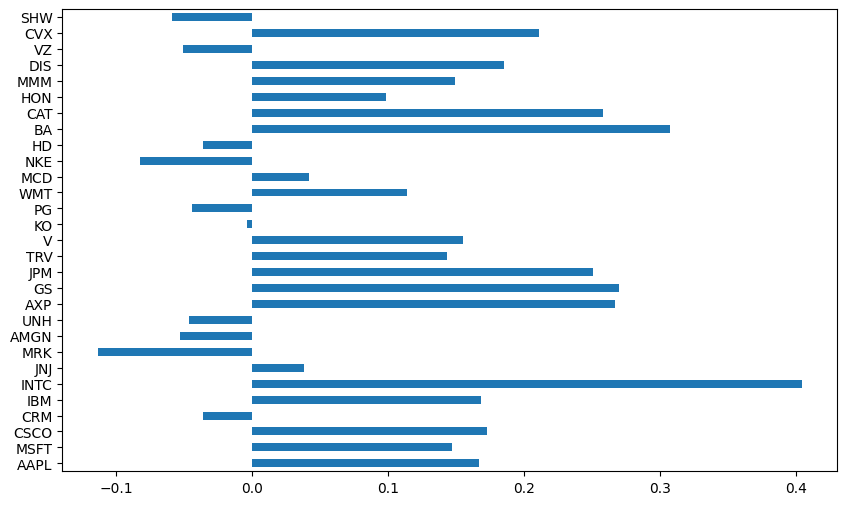

In [31]:
ret_bl = bl.bl_returns()
ret_bl.plot.barh(figsize=(10, 6))


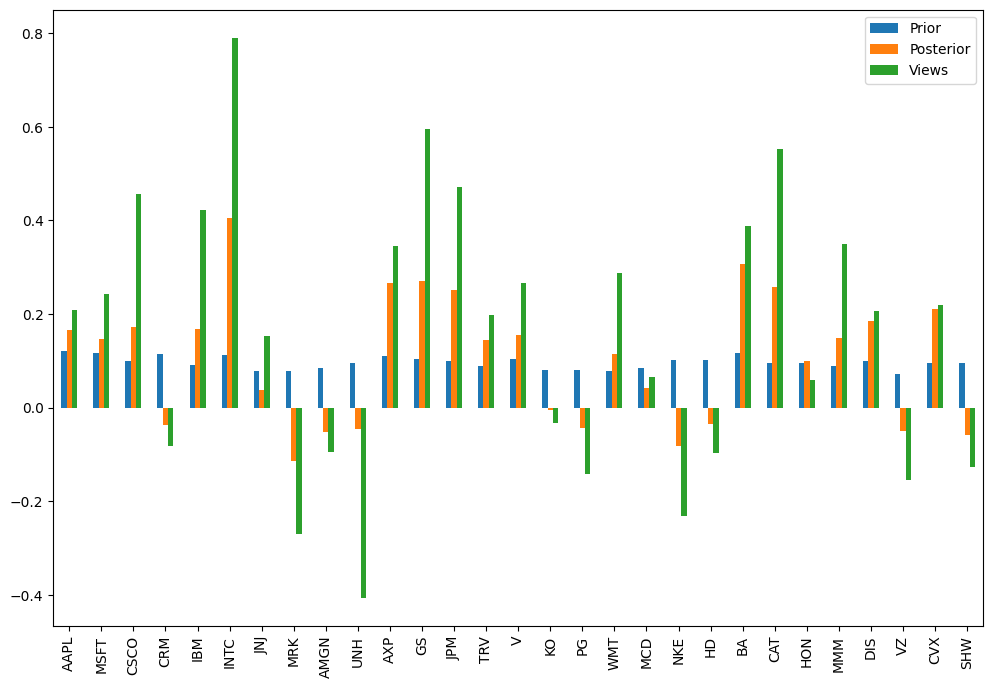

In [32]:
rets_df = pd.DataFrame(
    [market_prior, ret_bl, pd.Series(viewdict)], index=["Prior", "Posterior", "Views"]
).T
rets_df.plot.bar(figsize=(12, 8))


In [33]:
S_bl = bl.bl_cov()


### Optimal Weights Allocation

In [34]:
sector_indices = {}

for sector, tickers in tickers_dict.items():
    sector_indices[sector] = [filtered_df.columns.get_loc(t) for t in tickers]

sector_indices


{'information_technology': [0, 1, 2, 3, 4, 5],
 'health_care': [6, 7, 8, 9],
 'financials': [10, 11, 12, 13, 14],
 'consumer_staples': [15, 16, 17],
 'consumer_discretionary': [18, 19, 20],
 'industrials': [21, 22, 23, 24],
 'communication_services': [25, 26],
 'energy': [27],
 'materials': [28]}

In [35]:
from pypfopt import EfficientFrontier, objective_functions

ef = EfficientFrontier(ret_bl, S_bl)
ef.add_constraint(lambda w: w >= 0)
ef.add_constraint(lambda w: w <= 0.15)

ef.add_constraint(lambda w: sum(w[i] for i in sector_indices["information_technology"]) >= 0.25)
ef.add_constraint(lambda w: sum(w[i] for i in sector_indices["information_technology"]) <= 0.35)

ef.add_constraint(lambda w: sum(w[i] for i in sector_indices["health_care"]) >= 0.08)
ef.add_constraint(lambda w: sum(w[i] for i in sector_indices["health_care"]) <= 0.12)

ef.add_constraint(lambda w: sum(w[i] for i in sector_indices["financials"]) >= 0.15)
ef.add_constraint(lambda w: sum(w[i] for i in sector_indices["financials"]) <= 0.25)

ef.add_constraint(lambda w: sum(w[i] for i in sector_indices["consumer_staples"]) >= 0.08)
ef.add_constraint(lambda w: sum(w[i] for i in sector_indices["consumer_staples"]) <= 0.12)

ef.add_constraint(lambda w: sum(w[i] for i in sector_indices["consumer_discretionary"]) >= 0.08)
ef.add_constraint(lambda w: sum(w[i] for i in sector_indices["consumer_discretionary"]) <= 0.12)

ef.add_constraint(lambda w: sum(w[i] for i in sector_indices["industrials"]) >= 0.08)
ef.add_constraint(lambda w: sum(w[i] for i in sector_indices["industrials"]) <= 0.12)

ef.add_constraint(lambda w: sum(w[i] for i in sector_indices["communication_services"]) >= 0.03)
ef.add_constraint(lambda w: sum(w[i] for i in sector_indices["communication_services"]) <= 0.07)

ef.add_constraint(lambda w: sum(w[i] for i in sector_indices["energy"]) >= 0.02)
ef.add_constraint(lambda w: sum(w[i] for i in sector_indices["energy"]) <= 0.05)

ef.add_constraint(lambda w: sum(w[i] for i in sector_indices["materials"]) >= 0.01)
ef.add_constraint(lambda w: sum(w[i] for i in sector_indices["materials"]) <= 0.03)

ef.add_objective(objective_functions.L2_reg, gamma=0.25)
ef.max_sharpe()

weights = ef.clean_weights()
weights = {a: round(w, 4) for a, w in weights.items() if w > 0}
weights


{'AAPL': 0.0282,
 'MSFT': 0.0113,
 'CSCO': 0.0467,
 'IBM': 0.0517,
 'INTC': 0.15,
 'JNJ': 0.08,
 'AXP': 0.0679,
 'GS': 0.094,
 'JPM': 0.0801,
 'TRV': 0.0048,
 'V': 0.0031,
 'WMT': 0.08,
 'MCD': 0.08,
 'BA': 0.046,
 'CAT': 0.074,
 'DIS': 0.042,
 'CVX': 0.05,
 'SHW': 0.01}

In [36]:
final_weights = select_top_stocks(weights, top_n=12)
final_weights


{'INTC': 0.16659262549977788,
 'GS': 0.10439804531319413,
 'JPM': 0.08896046201688139,
 'JNJ': 0.08884940026654821,
 'WMT': 0.08884940026654821,
 'MCD': 0.08884940026654821,
 'CAT': 0.08218569524655708,
 'AXP': 0.07541092847623279,
 'IBM': 0.05741892492225678,
 'CVX': 0.05553087516659263,
 'CSCO': 0.05186583740559751,
 'BA': 0.051088405153265216}


🔹 Sector: information_technology
  → Fetching AAPL ...
  → Fetching MSFT ...
  → Fetching CSCO ...
  → Fetching CRM ...
  → Fetching IBM ...
  → Fetching INTC ...

🔹 Sector: health_care
  → Fetching JNJ ...
  → Fetching MRK ...
  → Fetching AMGN ...
  → Fetching UNH ...

🔹 Sector: financials
  → Fetching AXP ...
  → Fetching GS ...
  → Fetching JPM ...
  → Fetching TRV ...
  → Fetching V ...

🔹 Sector: consumer_staples
  → Fetching KO ...
  → Fetching PG ...
  → Fetching WMT ...

🔹 Sector: consumer_discretionary
  → Fetching MCD ...
  → Fetching NKE ...
  → Fetching HD ...

🔹 Sector: industrials
  → Fetching BA ...
  → Fetching CAT ...
  → Fetching HON ...
  → Fetching MMM ...

🔹 Sector: communication_services
  → Fetching DIS ...
  → Fetching VZ ...

🔹 Sector: energy
  → Fetching CVX ...

🔹 Sector: materials
  → Fetching SHW ...

✅ Data download complete!
Running backtest with 5% drift threshold...
Total number of rebalances: 0
Final portfolio value: $68,695,680.97
Total return: 37.3

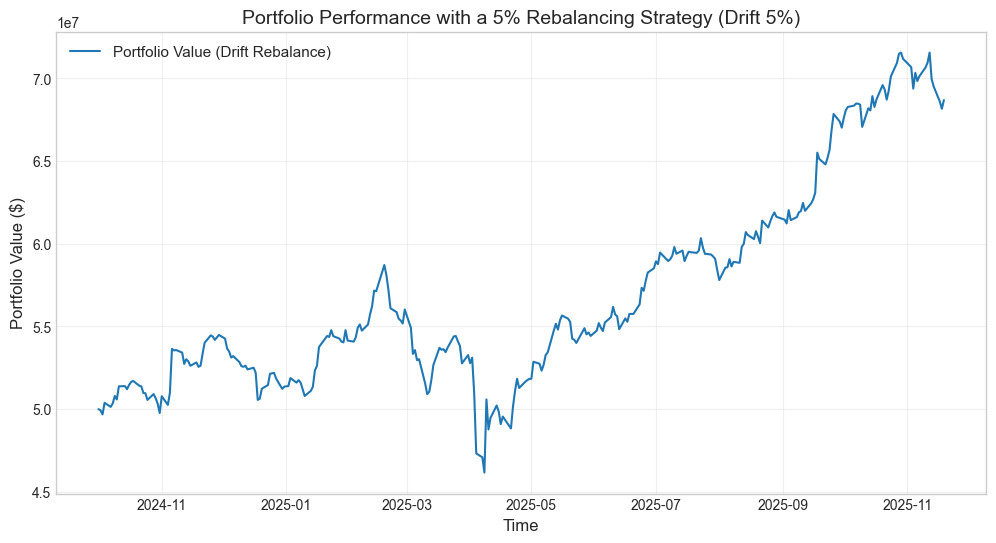

In [37]:
# Portfolio Performance with the 5% Rebalancing Strategy (5% Drift)
valid_tickers = list(final_weights.keys())
portfolio_df = get_historical_data(tickers_dict, start_date="2024-10-01", end_date="2025-11-20")
price_data_clean = portfolio_df[valid_tickers].dropna()
print("Running backtest with 5% drift threshold...")
port_value_drift, reb_dates = backtest_drift_rebalancing(
    price_data=price_data_clean,
    target_weights=final_weights,
    initial_capital=50_000_000,
    threshold=0.05,
)
print(f"Total number of rebalances: {len(reb_dates)}")
print(f"Final portfolio value: ${port_value_drift.iloc[-1]:,.2f}")
print(f"Total return: {(port_value_drift.iloc[-1] / 50_000_000 - 1) * 100:.2f}%")

plt.figure(figsize=(12, 6))
plt.plot(port_value_drift.index, port_value_drift.values, label="Portfolio Value (Drift Rebalance)")

if len(reb_dates) > 0:
    reb_values = port_value_drift.loc[reb_dates]
    plt.scatter(
        reb_dates, reb_values, color="red", marker="^", s=50, label="Rebalance Event", zorder=5
    )

plt.title("Portfolio Performance with a 5% Rebalancing Strategy (Drift 5%)")
plt.xlabel("Time")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [38]:
history, logs, stats = advanced_drift_backtest(
    price_data=price_data_clean,
    target_weights=final_weights,
    initial_capital=50_000_000,
    threshold=0.05,  # 5% Drift Threshold
    cost_rate=0.0020,  # 0.20% Transaction Cost
    verbose=True,
)


----------------------------------------
ADVANCED BACKTEST RESULTS
----------------------------------------
CAGR (Annual return): 32.49%
Sharpe Ratio:        1.39
Max Drawdown:        -21.42%
Number of rebalances:0
Total trading costs: $100,000.00
----------------------------------------


In [39]:
(rets_df.loc[final_weights.keys()] * 100)


,Prior,Posterior,Views
INTC,11.2990,40.4557,79.0281
GS,10.3935,26.9862,59.4811
JPM,9.9765,25.1026,47.1511
JNJ,7.7449,3.8342,15.3884
WMT,7.7613,11.3955,28.7979
MCD,8.5563,4.1728,6.4945
CAT,9.6036,25.8337,55.2398
AXP,10.9404,26.7137,34.5239
IBM,9.0349,16.8733,42.1713
CVX,9.6136,21.0854,22.0175


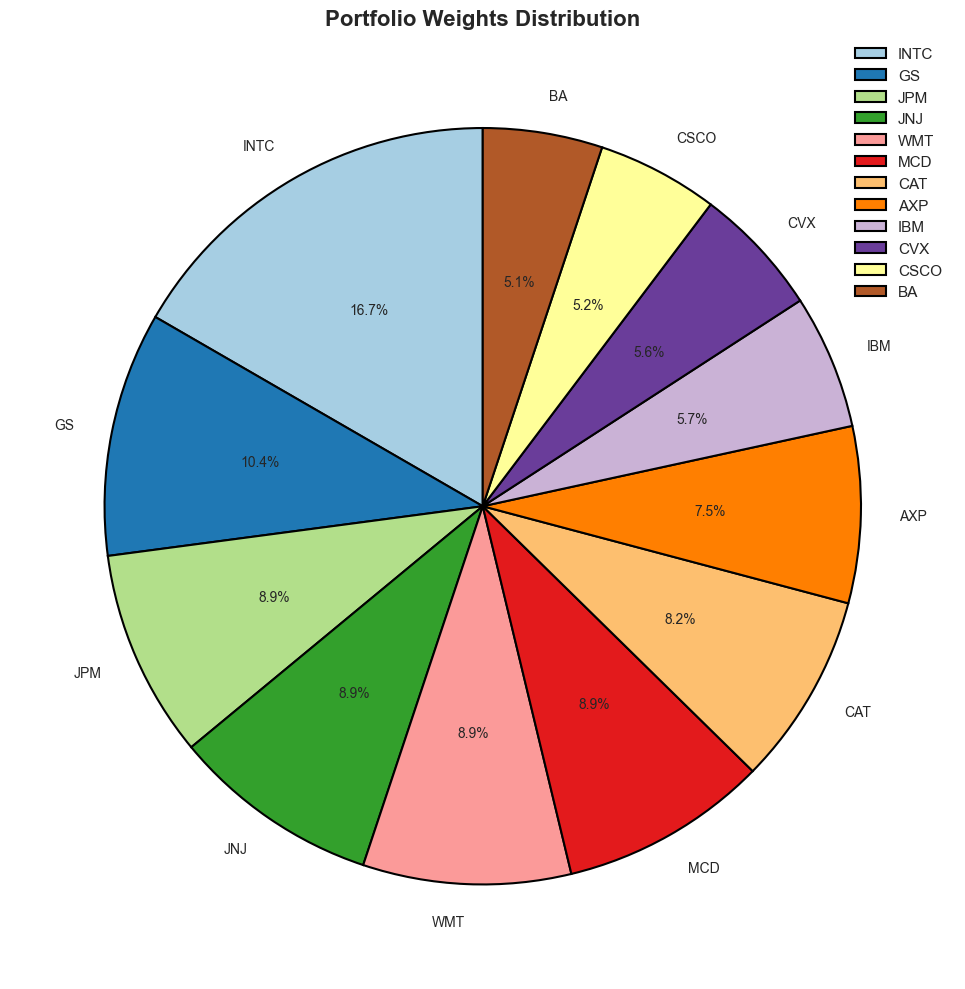

In [40]:
BlackLitterman().plot_portfolio(final_weights)


In [41]:
da = DiscreteAllocation(final_weights, filtered_df.iloc[-1], total_portfolio_value=50000000)
alloc, leftover = da.greedy_portfolio()
print(f"Leftover: ${leftover:.2f}")
alloc


Leftover: $12.12


{'INTC': 355057,
 'GS': 10811,
 'JPM': 21673,
 'JNJ': 28478,
 'WMT': 55551,
 'MCD': 15019,
 'CAT': 10704,
 'AXP': 14090,
 'IBM': 13427,
 'CVX': 19928,
 'CSCO': 50366,
 'BA': 16801}

### Backtesting Strategy

In [42]:
tickers = list(final_weights.keys())
print(tickers)


['INTC', 'GS', 'JPM', 'JNJ', 'WMT', 'MCD', 'CAT', 'AXP', 'IBM', 'CVX', 'CSCO', 'BA']


In [43]:
years = 5
endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days=365 * years)
close_price_df = yf.download(tickers, start=startDate, end=endDate)["Close"]
log_returns_bt = np.log(close_price_df / close_price_df.shift(1))
log_returns_bt = log_returns_bt.dropna()
log_returns_bt.head()


[*********************100%***********************]  12 of 12 completed


Ticker,AXP,BA,CAT,CSCO,CVX,GS,IBM,INTC,JNJ,JPM,MCD,WMT
Date,,,,,,,,,,,,
2020-12-08,-0.0034,-0.0067,0.0007,0.0005,0.0086,0.0016,0.0081,0.0097,0.0172,0.0010,-0.0024,0.0090
2020-12-09,-0.0149,-0.0192,0.0069,0.0072,-0.0121,0.0165,0.0086,-0.0123,0.0102,-0.0078,0.0014,-0.0079
2020-12-10,0.0012,0.0102,-0.0068,-0.0083,0.0317,0.0065,-0.0145,0.0038,-0.0056,-0.0065,-0.0031,-0.0047
2020-12-11,-0.0133,-0.0176,0.0025,0.0000,-0.0097,-0.0182,-0.0055,-0.0106,0.0046,-0.0059,-0.0013,-0.0003
2020-12-14,-0.0242,-0.0075,-0.0069,-0.0018,-0.0331,-0.0092,-0.0060,0.0148,-0.0257,-0.0106,0.0198,-0.0092


,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
EW,0.0060,0.0362,-0.0727,9.8572,0.0154,0.0239,-0.6466,-0.2465


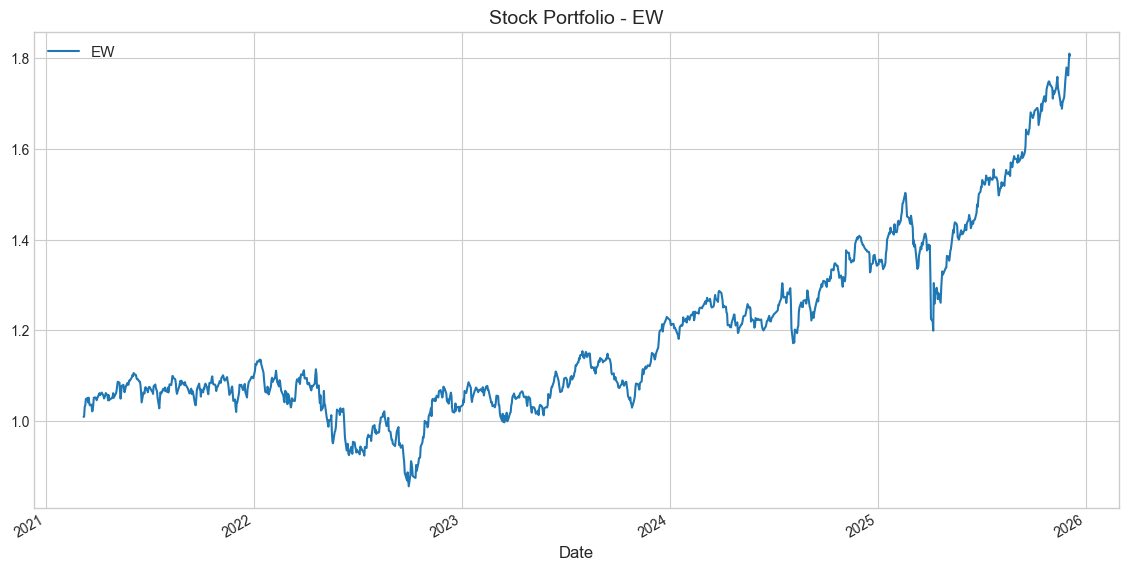

In [44]:
ewr = backtest_ws(
    log_returns_bt, estimation_window=60, weighting=weight_ew
)  # Equally weighted portfolio return
btr = pd.DataFrame({"EW": ewr})
(1 + btr).cumprod().plot(title="Stock Portfolio - EW")
summary_stats(btr.dropna())


,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
EW,0.0060,0.0362,-0.0727,9.8572,0.0154,0.0239,-0.6466,-0.2465
GMV-Sample,0.0039,0.0286,-0.4637,7.2726,0.0135,0.0194,-0.8890,-0.2187


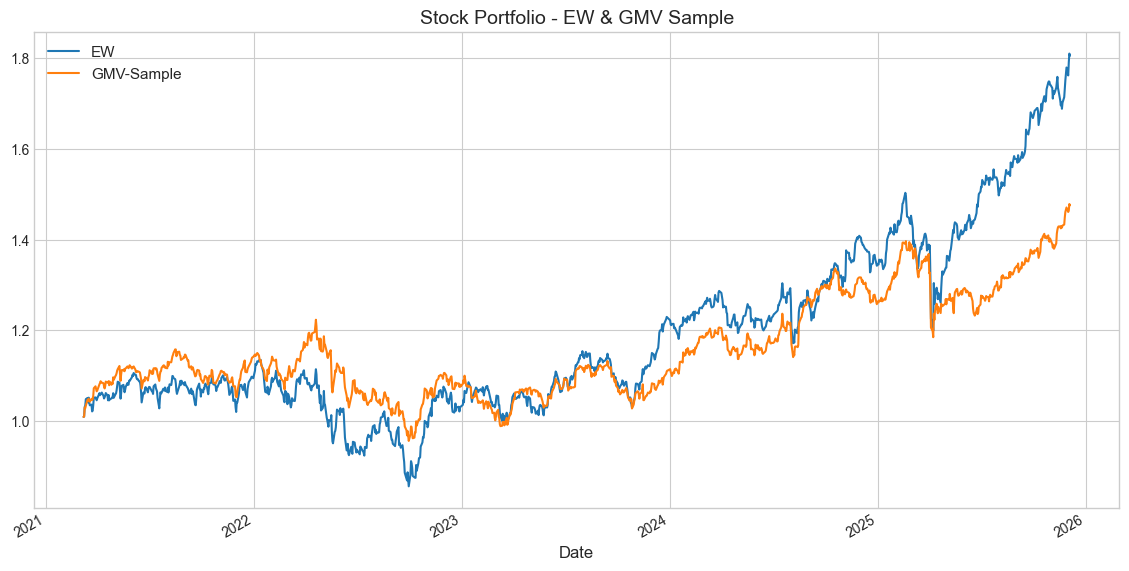

In [45]:
gmvr = backtest_ws(
    log_returns_bt, estimation_window=60, weighting=weight_gmv, cov_estimator=sample_cov
)  # GMV portfolio return
btr = pd.DataFrame({"EW": ewr, "GMV-Sample": gmvr})
(1 + btr).cumprod().plot(title="Stock Portfolio - EW & GMV Sample")
summary_stats(btr.dropna())


,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
EW,0.0036,0.0348,-0.2743,4.4145,0.0166,0.0232,-0.7390,-0.2465
GMV-Sample,0.0035,0.0282,-0.2765,5.1954,0.0133,0.0191,-0.9135,-0.2187
GMV-CCC,0.0031,0.0259,-0.2501,4.4006,0.0123,0.0173,-1.0102,-0.1717


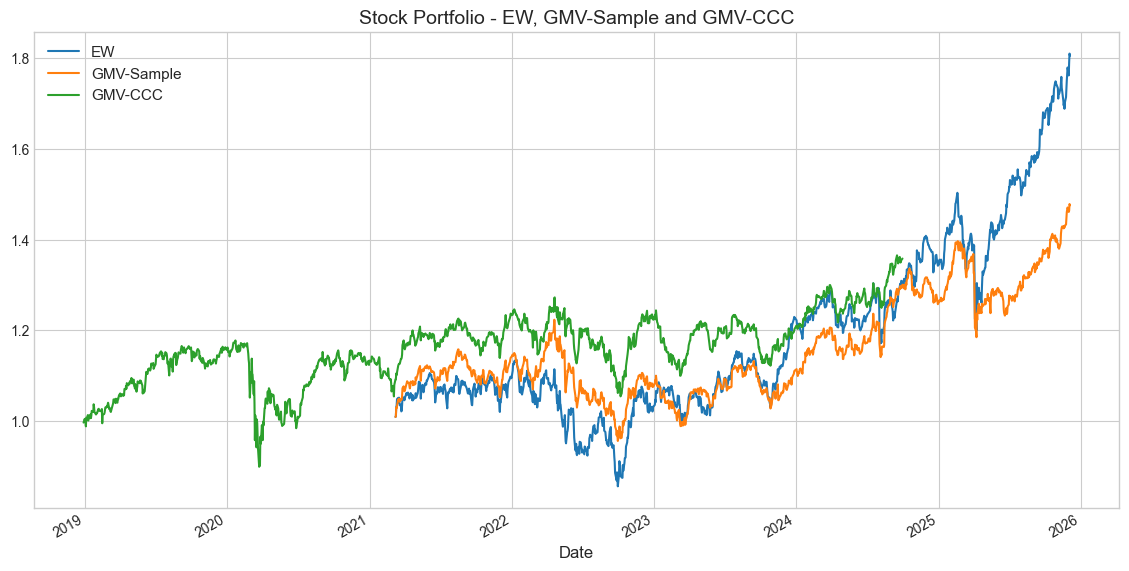

In [46]:
gmvccr = backtest_ws(
    log_returns, estimation_window=60, weighting=weight_gmv, cov_estimator=cc_cov
)  # GMV-CCC portfolio return
btr = pd.DataFrame({"EW": ewr, "GMV-Sample": gmvr, "GMV-CCC": gmvccr})
(1 + btr).cumprod().plot(title="Stock Portfolio - EW, GMV-Sample and GMV-CCC")
summary_stats(btr.dropna())


,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
EW,0.0036,0.0348,-0.2743,4.4145,0.0166,0.0232,-0.7390,-0.2465
GMV-Sample,0.0035,0.0282,-0.2765,5.1954,0.0133,0.0191,-0.9135,-0.2187
GMV-CCC,0.0031,0.0259,-0.2501,4.4006,0.0123,0.0173,-1.0102,-0.1717
GMV-Shrinkage,0.0033,0.0258,-0.2482,4.4994,0.0123,0.0174,-1.0064,-0.1767


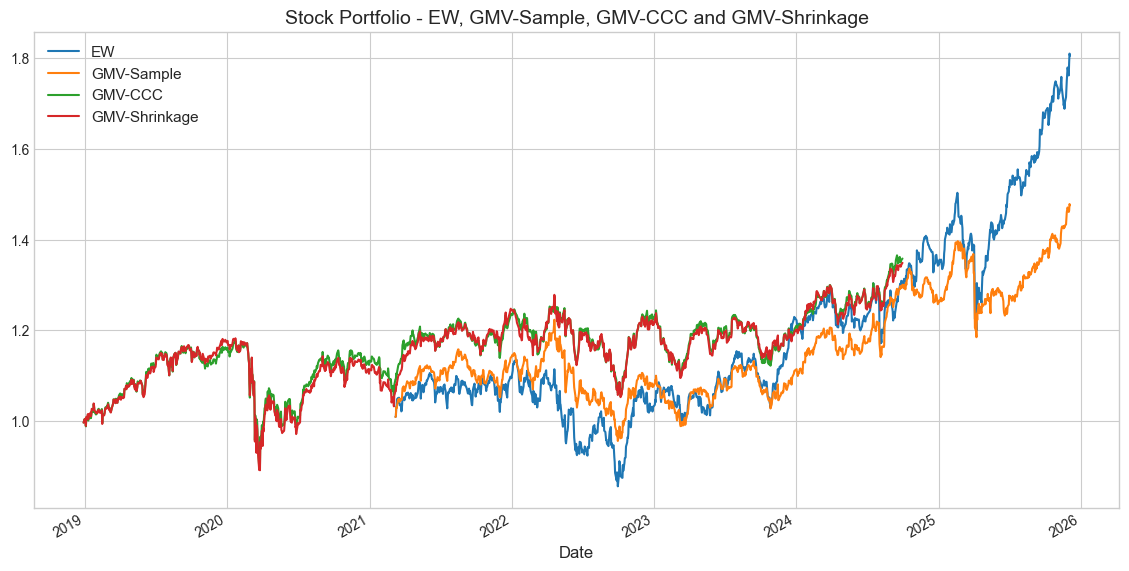

In [47]:
def factor_cov(r, **kwargs):
    n_factors = 2
    fa = FactorAnalysis(n_components=n_factors)
    fa.fit(r)
    factor_loadings = fa.components_.T
    factor_covariance = np.dot(factor_loadings, factor_loadings.T) + np.diag(fa.noise_variance_)
    return pd.DataFrame(factor_covariance, index=r.columns, columns=r.columns)


gmvsr = backtest_ws(
    log_returns, estimation_window=60, weighting=weight_gmv, cov_estimator=shrinkage_cov
)  # GMV-Shrinkage portfolio return
btr = pd.DataFrame({"EW": ewr, "GMV-Sample": gmvr, "GMV-CCC": gmvccr, "GMV-Shrinkage": gmvsr})
(1 + btr).cumprod().plot(title="Stock Portfolio - EW, GMV-Sample, GMV-CCC and GMV-Shrinkage")
summary_stats(btr.dropna())


,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
EW,0.0036,0.0348,-0.2743,4.4145,0.0166,0.0232,-0.7390,-0.2465
GMV-Sample,0.0035,0.0282,-0.2765,5.1954,0.0133,0.0191,-0.9135,-0.2187
GMV-CCC,0.0031,0.0259,-0.2501,4.4006,0.0123,0.0173,-1.0102,-0.1717
GMV-Shrinkage,0.0033,0.0258,-0.2482,4.4994,0.0123,0.0174,-1.0064,-0.1767
GMV-EWMA,0.0052,0.0267,-0.3235,4.8449,0.0126,0.0176,-0.9047,-0.1577


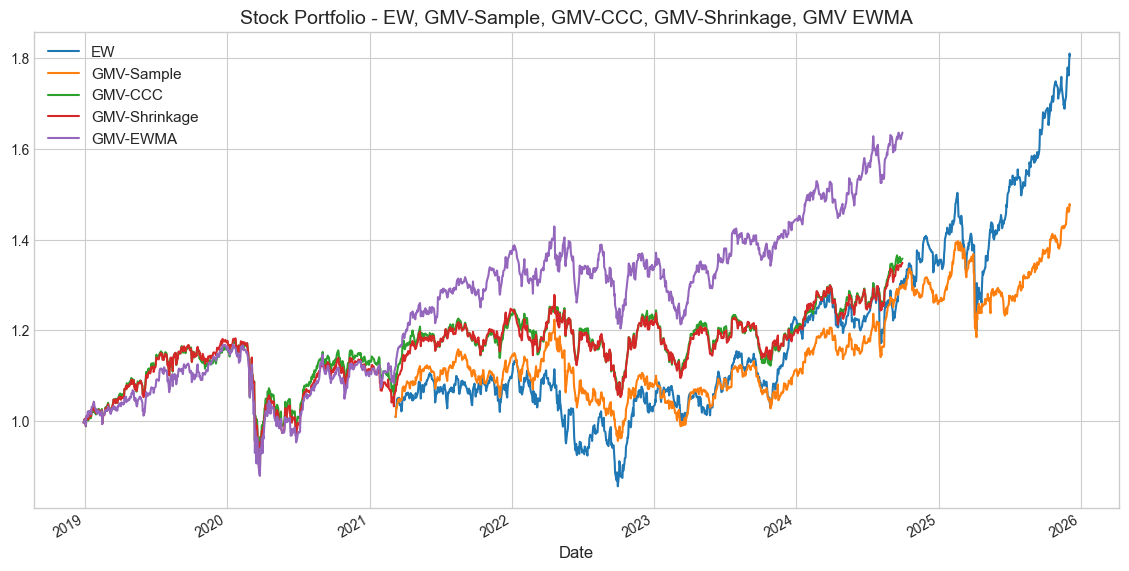

In [48]:
def riskmetrics_cov(returns, lambda_=0.94):
    n_assets = returns.shape[1]
    cov_matrix = np.zeros((n_assets, n_assets))

    # Compute EWMA covariance matrix
    for t in range(1, len(returns)):
        current_returns = returns.iloc[t].values.reshape(-1, 1)
        previous_cov_matrix = cov_matrix
        outer_product = current_returns @ current_returns.T

        cov_matrix = lambda_ * previous_cov_matrix + (1 - lambda_) * outer_product
    return cov_matrix


gmvewma = backtest_ws(
    log_returns, estimation_window=60, weighting=weight_gmv, cov_estimator=riskmetrics_cov
)  # GMV-EWMA portfolio return
btr = pd.DataFrame(
    {"EW": ewr, "GMV-Sample": gmvr, "GMV-CCC": gmvccr, "GMV-Shrinkage": gmvsr, "GMV-EWMA": gmvewma}
)
(1 + btr).cumprod().plot(title="Stock Portfolio - EW, GMV-Sample, GMV-CCC, GMV-Shrinkage, GMV EWMA")
summary_stats(btr.dropna())


# Portfolio Theory

## Traditional Approach (FF 3 Factors)

In [49]:
stock_list = list(final_weights.keys())
stock_weights = list(final_weights.values())
portfolio = filtered_df[stock_list]
portfolio = np.log(portfolio / portfolio.shift(1))
portfolio.dropna(inplace=True)
portfolio


,INTC,GS,JPM,JNJ,WMT,MCD,CAT,AXP,IBM,CVX,CSCO,BA
Date,,,,,,,,,,,,
2018-10-02,0.0349,0.0033,0.0041,0.0056,0.0079,-0.0090,0.0165,0.0045,0.0049,0.0028,0.0029,0.0106
2018-10-03,0.0136,0.0075,0.0093,-0.0104,-0.0114,-0.0032,0.0217,0.0006,-0.0035,0.0046,0.0026,0.0152
2018-10-04,-0.0130,-0.0013,0.0090,0.0023,0.0015,0.0069,-0.0093,-0.0030,-0.0125,-0.0029,-0.0088,-0.0059
2018-10-05,-0.0231,-0.0078,-0.0057,-0.0018,-0.0096,0.0046,-0.0222,-0.0047,-0.0152,0.0030,-0.0052,-0.0091
2018-10-08,0.0000,-0.0016,0.0061,0.0021,0.0147,0.0072,0.0003,-0.0022,-0.0043,-0.0039,-0.0128,-0.0018
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-24,0.0110,0.0012,0.0007,-0.0027,0.0042,0.0040,0.0390,-0.0041,0.0021,-0.0006,0.0063,-0.0031
2024-09-25,0.0315,-0.0139,-0.0066,-0.0135,0.0090,0.0007,-0.0201,-0.0002,0.0012,-0.0239,0.0025,-0.0233
2024-09-26,0.0160,0.0117,-0.0020,0.0049,-0.0183,0.0105,0.0331,0.0074,0.0099,-0.0138,0.0038,0.0154


In [50]:
weights_series = pd.Series(final_weights)
weighted_returns = portfolio.mul(weights_series, axis=1)
portfolio_returns = weighted_returns.sum(axis=1)
monthly_portfolio_returns = portfolio_returns.resample("M").sum()
monthly_portfolio_returns.index = monthly_portfolio_returns.index.to_period("M")


In [51]:
ff_factors_daily = pd.read_excel(r"F-F_Research_Data_Factors_daily.xlsx", engine="openpyxl")
ff_factors_daily = ff_factors_daily.rename(columns={"Unnamed: 0": "Date"})
ff_factors_daily["Date"] = pd.to_datetime(ff_factors_daily["Date"], format="%Y%m%d")
ff_factors_daily = ff_factors_daily.set_index("Date")
ff_factors_daily.head()


,Mkt-RF,SMB,HML,RF
Date,,,,
1926-07-01,0.0840,-0.2100,-0.2268,0.0076
1926-07-02,0.3780,-0.2772,-0.0504,0.0076
1926-07-06,0.1428,0.2520,-0.3276,0.0076
1926-07-07,0.0756,-0.4872,0.0168,0.0076
1926-07-08,0.1764,-0.3192,0.1596,0.0076


In [52]:
ff_factors_subset1 = ff_factors_daily[ff_factors_daily.index.isin(portfolio_returns.index)].copy()

ff_factors_subset1["Excess_Return"] = portfolio_returns - ff_factors_subset1["RF"]
ff_factors_subset1 = ff_factors_subset1.resample("M").sum()
ff_factors_subset1


,Mkt-RF,SMB,HML,RF,Excess_Return
Date,,,,,
2018-10-31,-6.6276,-2.9400,2.7720,0.1478,-0.1890
2018-11-30,1.5456,-0.5628,0.1428,0.1411,-0.1119
2018-12-31,-8.1228,-2.1420,-1.8648,0.1756,-0.2664
2019-01-31,6.9048,2.1840,-0.3696,0.1764,-0.1093
2019-02-28,2.8224,1.6884,-2.1672,0.1596,-0.1068
...,...,...,...,...,...
2024-05-31,3.5952,0.6468,-1.3188,0.3696,-0.3407
2024-06-30,2.3184,-2.4864,-2.7468,0.3511,-0.3518
2024-07-31,1.0752,5.4936,4.5276,0.3881,-0.3386


In [53]:
X = sm.add_constant(ff_factors_subset1[["Mkt-RF", "SMB", "HML"]])
y = ff_factors_subset1["Excess_Return"]
model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 3})
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:          Excess_Return   R-squared:                       0.183
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     8.348
Date:                Fri, 05 Dec 2025   Prob (F-statistic):           8.39e-05
Time:                        19:45:13   Log-Likelihood:                 39.567
No. Observations:                  72   AIC:                            -71.13
Df Residuals:                      68   BIC:                            -62.03
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1543      0.031     -4.975      0.0

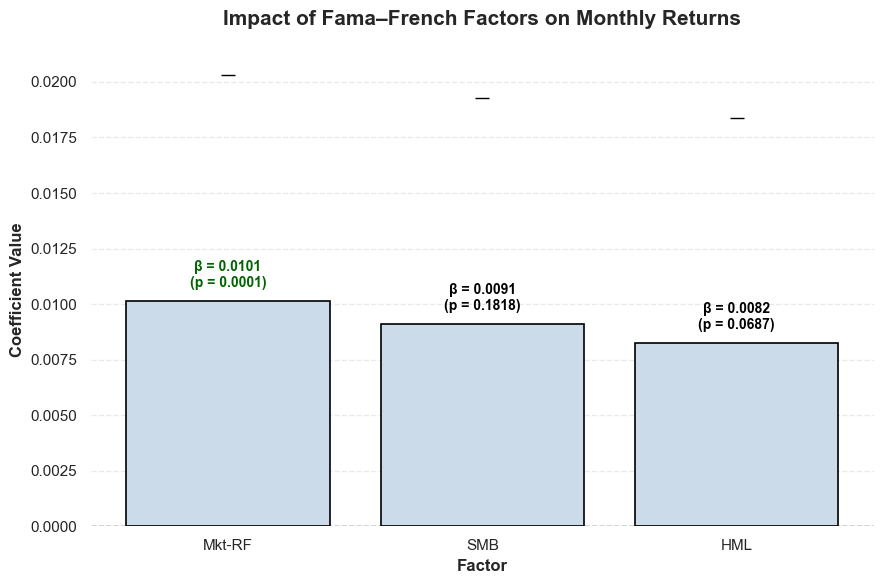

In [54]:
factors = model.params.index[1:]
coefficients = model.params.values[1:]
confidence_intervals = model.conf_int().diff(axis=1).iloc[1]

ols_data = pd.DataFrame(
    {
        "Factor": factors,
        "Coefficient": coefficients,
        "Confidence_Lower": confidence_intervals[0],
        "Confidence_Upper": confidence_intervals[1],
    }
)

FamaFrench().plot_impact(model, ols_data)


## Modern Approach (with Algorithmic Trading)

### Data Model

In [55]:
ff_factors_subset2 = ff_factors_daily[ff_factors_daily.index.isin(portfolio_returns.index)].copy()

ff_factors_subset2["Returns"] = portfolio_returns
ff_factors_subset2.drop(columns=["RF"], inplace=True)
ff_factors_subset2


,Mkt-RF,SMB,HML,Returns
Date,,,,
2018-10-02,-0.1764,-0.8232,0.5040,0.0098
2018-10-03,0.1680,0.7056,0.4200,0.0045
2018-10-04,-0.7812,-0.8904,1.3272,-0.0032
2018-10-05,-0.5376,-0.3612,0.3276,-0.0094
2018-10-08,-0.1428,-0.3360,1.0248,0.0011
...,...,...,...,...
2024-09-24,0.2016,0.1008,-0.4872,0.0057
2024-09-25,-0.2436,-0.5544,-0.5880,-0.0011
2024-09-26,0.3528,0.1764,0.3612,0.0075


### Features and Target

In [56]:
X = ff_factors_subset2.drop(["Returns"], axis=1)
y = ff_factors_subset2.loc[:, "Returns"]


### Train Test Split

In [57]:
split = int(0.8 * len(X))
X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]
test = ff_factors_subset2["Returns"][split:]
test


Date
2023-07-20    0.0091
2023-07-21    0.0006
2023-07-24    0.0050
2023-07-25    0.0010
2023-07-26    0.0061
               ...  
2024-09-24    0.0057
2024-09-25   -0.0011
2024-09-26    0.0075
2024-09-27    0.0027
2024-09-30   -0.0025
Name: Returns, Length: 302, dtype: float64

### Prediction Model

In [58]:
lin_reg_model = LinearRegression(fit_intercept=True)
lin_reg_model = lin_reg_model.fit(X_train, y_train)
predictions = lin_reg_model.predict(X_test)


In [59]:
y_test = y_test.to_frame()


In [60]:
signals_df = y_test.copy()

y_test["Predictions"] = predictions
y_test["Returns"] = test

# Add "Buy Signal" column based on whether day's predictions were greater than the day's actual returns:
y_test["Buy Signal"] = np.where(y_test["Predictions"] > y_test["Returns"], 1.0, 0.0)

y_test = y_test.dropna()
y_test.head()


,Returns,Predictions,Buy Signal
Date,,,
2023-07-20,0.0091,-0.0051,0.0000
2023-07-21,0.0006,-0.0017,0.0000
2023-07-24,0.0050,0.0061,1.0000
2023-07-25,0.0010,-0.0007,0.0000
2023-07-26,0.0061,0.0033,0.0000


In [61]:
signals_df = AlgorithmicTrading().generate_signals(y_test)
signals_df.head(10)


,Returns,Predictions,Buy Signal,Position,Entry/Exit,Entry/Exit Position,Portfolio Holdings,Portfolio Cash,Portfolio Total,Portfolio Daily Returns,Portfolio Cumulative Returns
Date,,,,,,,,,,,
2023-07-24,0.0050,0.0061,1.0000,"2,000.0000",1.0000,"2,000.0000",9.9836,"99,990.0164","100,000.0000",0.0000,0.0000
2023-07-25,0.0010,-0.0007,0.0000,0.0000,-1.0000,"-2,000.0000",0.0000,"99,992.0660","99,992.0660",-0.0001,-0.0001
2023-07-26,0.0061,0.0033,0.0000,0.0000,0.0000,0.0000,0.0000,"99,992.0660","99,992.0660",0.0000,-0.0001
2023-07-27,-0.0015,-0.0055,0.0000,0.0000,0.0000,0.0000,-0.0000,"99,992.0660","99,992.0660",0.0000,-0.0001
2023-07-28,0.0128,0.0092,0.0000,0.0000,0.0000,0.0000,0.0000,"99,992.0660","99,992.0660",0.0000,-0.0001
2023-07-31,-0.0024,0.0010,1.0000,"2,000.0000",1.0000,"2,000.0000",-4.8410,"99,996.9070","99,992.0660",0.0000,-0.0001
2023-08-01,0.0068,-0.0023,0.0000,0.0000,-1.0000,"-2,000.0000",0.0000,"100,010.5884","100,010.5884",0.0002,0.0001
2023-08-02,-0.0132,-0.0124,1.0000,"2,000.0000",1.0000,"2,000.0000",-26.3718,"100,036.9602","100,010.5884",0.0000,0.0001
2023-08-03,0.0030,-0.0017,0.0000,0.0000,-1.0000,"-2,000.0000",0.0000,"100,042.9947","100,042.9947",0.0003,0.0004


In [62]:
AlgorithmicTrading().algo_evaluation(signals_df)


,Backtest
Annual Return,0.6240
Cumulative Returns,0.7451
Annual Volatility,0.2825
Sharpe Ratio,2.2086
Sortino Ratio,3.8042


In [63]:
AlgorithmicTrading().algo_vs_underlying(signals_df)


,Algo,Underlying
Annual Return,0.6240,0.1171
Cumulative Returns,0.7451,0.1340
Annual Volatility,0.2825,0.1510
Sharpe Ratio,2.2086,0.7757
Sortino Ratio,3.8042,1.0139


In [64]:
trade_evaluation_df = AlgorithmicTrading().trade_evaluation(signals_df)
trade_evaluation_df


,Entry Date,Exit Date,Shares,Entry Share Price,Exit Share Price,Entry Portfolio Holding,Exit Portfolio Holding,Profit/Loss
0,2023-07-24,2023-07-25,"2,000.0000",0.0050,0.0010,"100,000.0000","99,992.0660",-7.9340
1,2023-07-31,2023-08-01,"2,000.0000",-0.0024,0.0068,"99,992.0660","100,010.5884",18.5224
2,2023-08-02,2023-08-03,"2,000.0000",-0.0132,0.0030,"100,010.5884","100,042.9947",32.4063
3,2023-08-04,2023-08-07,"2,000.0000",-0.0035,0.0113,"100,042.9947","100,072.5667",29.5720
4,2023-08-08,2023-08-09,"2,000.0000",-0.0044,-0.0080,"100,072.5667","100,065.4399",-7.1268
...,...,...,...,...,...,...,...,...
71,2024-08-27,2024-08-29,"2,000.0000",-0.0003,0.0102,"100,589.5523","100,610.5668",21.0145
72,2024-09-03,2024-09-05,"2,000.0000",-0.0326,-0.0057,"100,610.5668","100,664.4284",53.8616
73,2024-09-10,2024-09-11,"2,000.0000",-0.0109,0.0104,"100,664.4284","100,706.9838",42.5554
74,2024-09-12,2024-09-13,"2,000.0000",0.0028,0.0076,"100,706.9838","100,716.5827",9.5989


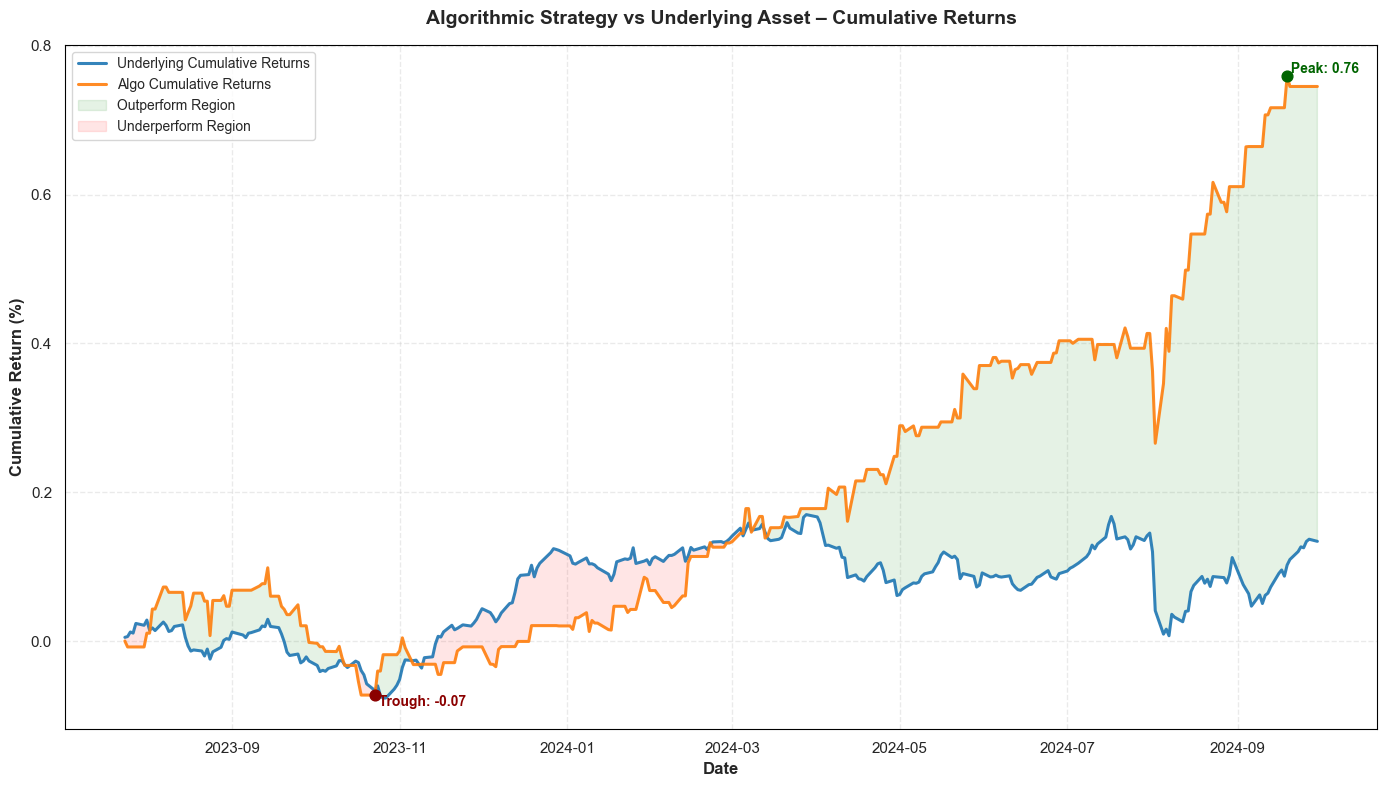

,Underlying Cumulative Returns,Algo Cumulative Returns
Date,,
2023-07-24,0.0050,0.0000
2023-07-25,0.0060,-0.0079
2023-07-26,0.0122,-0.0079
2023-07-27,0.0107,-0.0079
2023-07-28,0.0237,-0.0079
...,...,...
2024-09-24,0.1266,0.7451
2024-09-25,0.1253,0.7451
2024-09-26,0.1338,0.7451


In [65]:
AlgorithmicTrading().underlying_returns(signals_df)


## Risk Measurements/Estimations (VaR using Monte Carlo Simulation Method)

In [66]:
yearly_log_returns = portfolio.resample("Y").sum()
yearly_log_returns


,INTC,GS,JPM,JNJ,WMT,MCD,CAT,AXP,IBM,CVX,CSCO,BA
Date,,,,,,,,,,,,
2018-12-31,0.0166,-0.2952,-0.1437,-0.0729,-0.0079,0.0695,-0.1746,-0.1204,-0.2845,-0.1243,-0.1136,-0.1655
2019-12-31,0.2678,0.3399,0.3870,0.1503,0.2636,0.1308,0.1783,0.2815,0.2117,0.1421,0.1294,0.0328
2020-12-31,-0.1589,0.1609,-0.0569,0.1028,0.2096,0.1070,0.2387,-0.0115,-0.0117,-0.3005,-0.0355,-0.4140
2021-12-31,0.0588,0.3894,0.2449,0.1083,0.0195,0.2452,0.1480,0.3140,0.1540,0.3801,0.3768,-0.0614
2022-12-31,-0.6282,-0.0820,-0.1351,0.0580,-0.0046,0.0051,0.1706,-0.0890,0.1011,0.4603,-0.2544,-0.0553
2023-12-31,0.6656,0.1476,0.2672,-0.0897,0.1212,0.1403,0.2307,0.2521,0.1976,-0.1466,0.0889,0.3136
2024-12-31,-0.7484,0.2685,0.2323,0.0566,0.4393,0.0446,0.2921,0.3792,0.3291,0.0193,0.0765,-0.5391


In [67]:
cov_estimator = CovarianceShrinkage(
    yearly_log_returns, returns_data=True, delta=optimal_shrinkage_coef
)
vcv_matrix = cov_estimator.ledoit_wolf()
vcv_matrix


,INTC,GS,JPM,JNJ,WMT,MCD,CAT,AXP,IBM,CVX,CSCO,BA
INTC,34.3875,2.0071,5.3728,-1.6860,-2.5266,2.8745,-1.4744,2.1470,-1.2357,-5.1614,4.7641,12.7381
GS,2.0071,12.7484,5.2558,1.7076,2.5811,1.3824,3.2000,5.1966,4.5338,1.4410,4.6660,-0.1268
JPM,5.3728,5.2558,11.3599,0.6884,2.2160,1.1269,1.9652,5.0489,3.8814,0.7315,4.0501,2.2022
JNJ,-1.6860,1.7076,0.6884,6.7213,0.6086,0.1796,0.7328,0.6395,0.8560,1.2257,0.6774,-1.0656
WMT,-2.5266,2.5811,2.2160,0.6086,9.0020,-0.2490,1.8797,2.4932,2.4162,-1.8187,0.7981,-2.8383
MCD,2.8745,1.3824,1.1269,0.1796,-0.2490,6.4400,0.0850,0.9694,0.2628,0.1563,1.6462,0.9313
CAT,-1.4744,3.2000,1.9652,0.7328,1.8797,0.0850,8.4947,2.2191,3.1127,0.2996,0.9460,-0.5917
AXP,2.1470,5.1966,5.0489,0.6395,2.4932,0.9694,2.2191,10.8949,4.0819,0.8896,4.0152,0.4307
IBM,-1.2357,4.5338,3.8814,0.8560,2.4162,0.2628,3.1127,4.0819,10.3942,2.1325,2.1313,0.3328
CVX,-5.1614,1.4410,0.7315,1.2257,-1.8187,0.1563,0.2996,0.8896,2.1325,15.1097,0.8101,1.9481


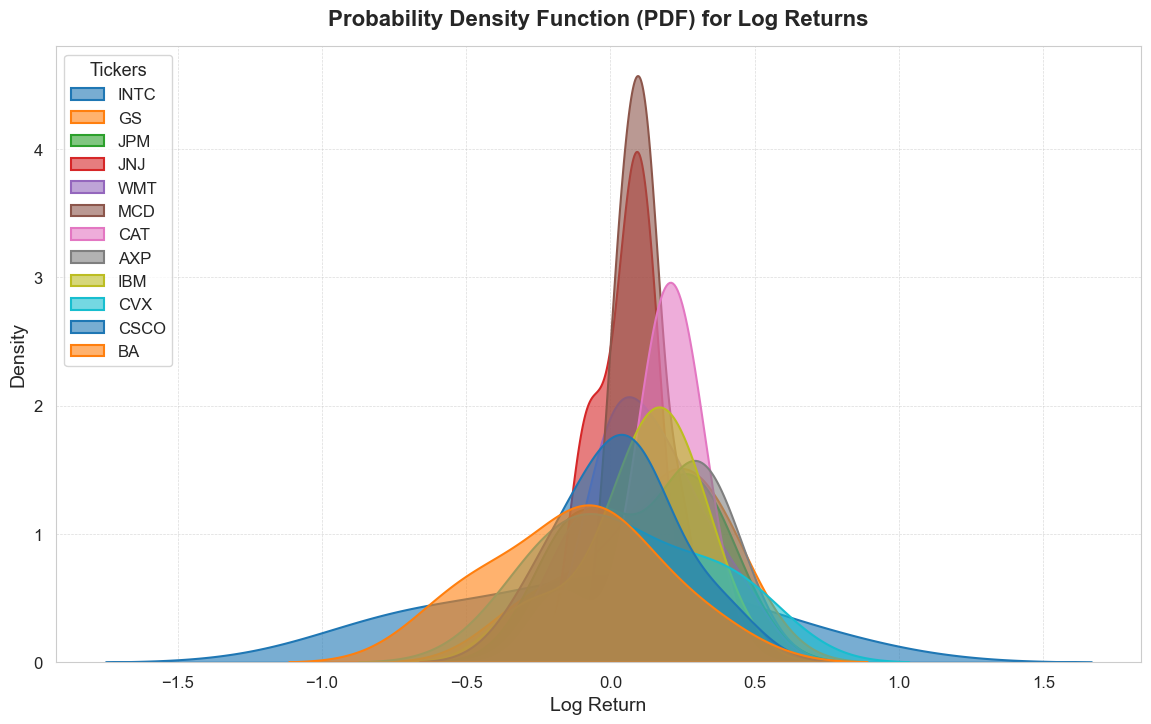

In [68]:
TranscendentalKernel().plot_pdf(yearly_log_returns)


In [69]:
pdf_dict = {}

for column in yearly_log_returns.columns:
    kde = gaussian_kde(yearly_log_returns[column])

    min_return = yearly_log_returns[column].min()
    max_return = yearly_log_returns[column].max()
    return_range = np.linspace(min_return, max_return, 1000)

    pdf_values = kde(return_range)

    pdf_dict[column] = {"returns": return_range, "pdf": pdf_values}


In [70]:
simulation = TranscendentalKernel().percentile_to_percentile_mapping(
    10000, yearly_log_returns, vcv_matrix, pdf_dict
)
simulation


,INTC,GS,JPM,JNJ,WMT,MCD,CAT,AXP,IBM,CVX,CSCO,BA
0,-0.7484,0.3894,-0.1320,0.1503,-0.0079,0.0051,0.2921,0.3792,0.3291,-0.2052,0.3760,-0.5391
1,-0.7484,-0.2952,-0.1437,-0.0897,0.1845,0.0051,-0.1746,-0.1204,-0.2845,0.4603,-0.2544,0.3136
2,0.6656,0.3894,-0.1437,-0.0897,-0.0079,0.2452,-0.1746,-0.1204,0.3291,-0.3005,0.3768,-0.5391
3,-0.7484,-0.2952,-0.1437,0.1503,0.4393,0.2452,-0.1746,0.3792,-0.2845,-0.3005,0.3768,-0.5391
4,-0.7484,-0.2952,-0.1437,0.1503,0.4393,0.0051,-0.1746,-0.1204,-0.2845,-0.3005,-0.2544,-0.5391
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.0263,0.3894,-0.1437,-0.0897,0.4393,0.2452,0.1155,-0.1204,0.3291,-0.3005,0.3768,-0.5391
9996,-0.7484,-0.2952,-0.1437,0.1503,-0.0079,0.0859,-0.1552,0.3792,-0.2378,0.4603,-0.2544,-0.5391
9997,0.6656,0.3894,0.0968,-0.0897,-0.0079,0.2452,-0.1746,-0.1204,-0.2845,-0.3005,-0.2544,0.0492
9998,-0.7484,-0.2952,-0.1437,-0.0897,-0.0079,0.2452,0.2921,-0.1204,-0.2845,0.4603,-0.2544,0.3136


In [71]:
initial_value = 50000000
beginning_value = OrderedDict((key, value * initial_value) for key, value in final_weights.items())
beginning_value


OrderedDict([('INTC', 8329631.274988894),
             ('GS', 5219902.265659707),
             ('JPM', 4448023.100844069),
             ('JNJ', 4442470.01332741),
             ('WMT', 4442470.01332741),
             ('MCD', 4442470.01332741),
             ('CAT', 4109284.762327854),
             ('AXP', 3770546.4238116397),
             ('IBM', 2870946.246112839),
             ('CVX', 2776543.7583296313),
             ('CSCO', 2593291.8702798756),
             ('BA', 2554420.2576632607)])

In [72]:
ending_value = (beginning_value * (1 + simulation)).sum(axis=1)
ending_value


0      48,470,111.4107
1      41,460,528.0366
2      56,132,409.6610
3      43,955,653.0045
4      39,368,226.9538
             ...      
9995   53,986,042.2918
9996   41,950,471.6356
9997   55,306,459.3080
9998   43,590,663.0288
9999   59,604,603.1346
Length: 10000, dtype: float64

In [73]:
VaR_95_value = TranscendentalKernel().calculate_var(ending_value, 0.05)
VaR_99_value = TranscendentalKernel().calculate_var(ending_value, 0.01)

print(f"VaR at 95% confidence level (5th percentile): {VaR_95_value}")
print(f"VaR at 99% confidence level (1st percentile): {VaR_99_value}")


VaR at 95% confidence level (5th percentile): 40372667.139985636
VaR at 99% confidence level (1st percentile): 38199140.0752621


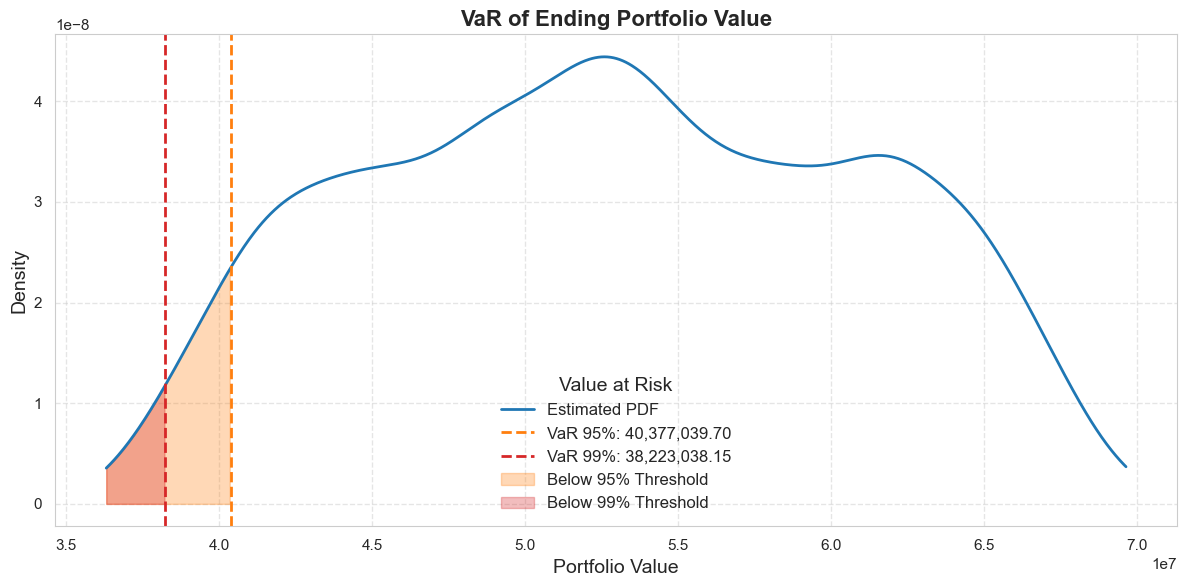

In [74]:
TranscendentalKernel().plot_var(ending_value)


# Scenario Analysis

## Bullish Scenario

In [75]:
datafetcher = DataFetcher(verbose=True)

bullish_data = {}
start_date = "2020-01-01"
end_date = "2021-12-31"

for ticker in portfolio.columns:
    print(f"Fetching data for ticker: {ticker}")
    bullish_data[ticker] = datafetcher.yfinance_adj_close(ticker, start=start_date, end=end_date)

bullish = pd.concat(bullish_data.values(), axis=1)
bullish.columns = portfolio.columns
bullish.ffill(inplace=True)
bullish.bfill(inplace=True)
bullish


Fetching data for ticker: INTC
Fetching data for ['INTC'] from 2020-01-01 to 2021-12-31 (interval='1d')
Fetching data for ticker: GS
Fetching data for ['GS'] from 2020-01-01 to 2021-12-31 (interval='1d')
Fetching data for ticker: JPM
Fetching data for ['JPM'] from 2020-01-01 to 2021-12-31 (interval='1d')
Fetching data for ticker: JNJ
Fetching data for ['JNJ'] from 2020-01-01 to 2021-12-31 (interval='1d')
Fetching data for ticker: WMT
Fetching data for ['WMT'] from 2020-01-01 to 2021-12-31 (interval='1d')
Fetching data for ticker: MCD
Fetching data for ['MCD'] from 2020-01-01 to 2021-12-31 (interval='1d')
Fetching data for ticker: CAT
Fetching data for ['CAT'] from 2020-01-01 to 2021-12-31 (interval='1d')
Fetching data for ticker: AXP
Fetching data for ['AXP'] from 2020-01-01 to 2021-12-31 (interval='1d')
Fetching data for ticker: IBM
Fetching data for ['IBM'] from 2020-01-01 to 2021-12-31 (interval='1d')
Fetching data for ticker: CVX
Fetching data for ['CVX'] from 2020-01-01 to 2021-12

,INTC,GS,JPM,JNJ,WMT,MCD,CAT,AXP,IBM,CVX,CSCO,BA
Date,,,,,,,,,,,,
2020-01-02,53.6665,203.1826,119.5734,123.2902,36.5081,174.7648,132.8749,116.6386,100.0137,92.9179,40.6889,331.3486
2020-01-03,53.0137,200.8067,117.9954,121.8628,36.1858,174.1468,131.0301,115.4801,99.2161,92.5965,40.0251,330.7919
2020-01-06,52.8638,202.8618,117.9016,121.7107,36.1121,176.1052,130.9418,114.9796,99.0389,92.2828,40.1679,331.7661
2020-01-07,51.9817,204.1971,115.8972,122.4540,35.7776,176.3663,129.2117,114.3772,99.1053,91.1043,39.9074,335.2852
2020-01-08,52.0170,206.1655,116.8013,122.4371,35.6548,179.2212,130.3592,116.3513,99.9325,90.0637,39.9326,329.4101
...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-23,47.5883,347.9179,141.5857,149.6506,44.2228,242.6865,191.4157,156.1534,111.5499,99.0573,55.3153,204.2200
2021-12-27,48.1726,350.6286,142.3961,150.9136,44.6254,244.7762,191.5827,156.3435,112.3953,101.0825,56.3278,203.1700
2021-12-28,48.0057,350.2401,142.8282,151.5184,45.2659,244.4476,191.8056,156.3626,113.2578,100.8868,56.4255,206.1300


In [76]:
bullish_log_returns = dataprocessor.return_from_prices(bullish, log_returns=True)
bullish_log_returns = bullish_log_returns.resample("Y").sum() * weights_series
cov_estimator = CovarianceShrinkage(
    bullish_log_returns, returns_data=True, delta=optimal_shrinkage_coef
)
bullish_vcv = cov_estimator.ledoit_wolf()
bullish_vcv


,INTC,GS,JPM,JNJ,WMT,MCD,CAT,AXP,IBM,CVX,CSCO,BA
INTC,0.0996,0.0667,0.0701,0.0030,-0.0445,0.0336,-0.0154,0.0648,0.0256,0.0958,0.0563,0.0489
GS,0.0667,0.0447,0.0470,0.0020,-0.0298,0.0225,-0.0103,0.0434,0.0171,0.0642,0.0377,0.0328
JPM,0.0701,0.0470,0.0494,0.0021,-0.0313,0.0236,-0.0108,0.0456,0.0180,0.0675,0.0396,0.0345
JNJ,0.0030,0.0020,0.0021,0.0001,-0.0013,0.0010,-0.0005,0.0019,0.0008,0.0029,0.0017,0.0015
WMT,-0.0445,-0.0298,-0.0313,-0.0013,0.0199,-0.0150,0.0069,-0.0289,-0.0114,-0.0428,-0.0251,-0.0219
MCD,0.0336,0.0225,0.0236,0.0010,-0.0150,0.0113,-0.0052,0.0219,0.0086,0.0323,0.0190,0.0165
CAT,-0.0154,-0.0103,-0.0108,-0.0005,0.0069,-0.0052,0.0024,-0.0100,-0.0040,-0.0148,-0.0087,-0.0076
AXP,0.0648,0.0434,0.0456,0.0019,-0.0289,0.0219,-0.0100,0.0422,0.0166,0.0624,0.0366,0.0319
IBM,0.0256,0.0171,0.0180,0.0008,-0.0114,0.0086,-0.0040,0.0166,0.0066,0.0246,0.0145,0.0126
CVX,0.0958,0.0642,0.0675,0.0029,-0.0428,0.0323,-0.0148,0.0624,0.0246,0.0922,0.0541,0.0471


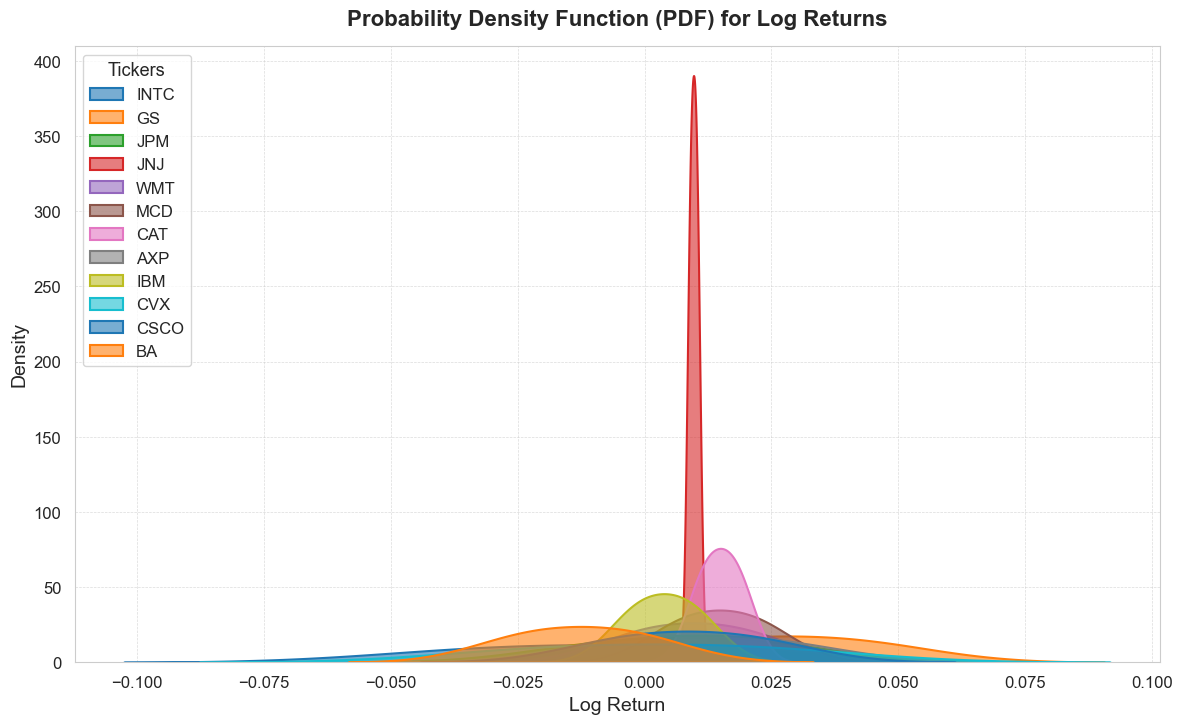

In [77]:
TranscendentalKernel().plot_pdf(bullish_log_returns)


In [78]:
pdf_dict_bullish = {}

for column in bullish_log_returns.columns:
    kde = gaussian_kde(bullish_log_returns[column])

    min_return = bullish_log_returns[column].min()
    max_return = bullish_log_returns[column].max()
    return_range = np.linspace(min_return, max_return, 1000)

    pdf_values = kde(return_range)

    pdf_dict_bullish[column] = {"returns": return_range, "pdf": pdf_values}


In [79]:
simulation = TranscendentalKernel().percentile_to_percentile_mapping(
    37, bullish_log_returns, bullish_vcv, pdf_dict_bullish
)
port_return_in_bullish = simulation.sum(axis=1)

total_income_2024 = 0
start_year = 2024
end_year = 2025
initial_investment = 50_000_000
initial_wealth = initial_investment + total_income_2024
years = list(range(start_year, end_year + 1))
surplus_or_deficit = [0 for _ in range(end_year - start_year + 1)]

port_return_in_bullish = port_return_in_bullish[: len(years)]


wealth_at_beginning = [initial_wealth]
wealth_at_end = []
additions_or_drawdowns = []

for i in range(len(years)):
    if i > 0:
        wealth_at_beginning.append(wealth_at_end[i - 1] + surplus_or_deficit[i])
        additions_or_drawdowns.append(surplus_or_deficit[i])

    wealth_end = wealth_at_beginning[i] * (1 + port_return_in_bullish[i])
    wealth_at_end.append(wealth_end)

data = {
    "Year": years,
    "Wealth at Beginning of the Year": wealth_at_beginning,
    "Return on Portfolio": port_return_in_bullish,
    "Wealth at the End of the Year": wealth_at_end,
    "Addition/Drawdown": surplus_or_deficit,
}

bullish_case = pd.DataFrame(data)
final_wealth = bullish_case["Wealth at the End of the Year"].iloc[-1]
total_return = (final_wealth / bullish_case["Wealth at Beginning of the Year"].iloc[0]) - 1

print("📈 FIUAM Active Mutual Fund (Bullish Scenario)")
print("----------------------------------------------------")
for i, row in bullish_case.iterrows():
    print(f"Year {int(row['Year'])}:")
    print(f"  • Return on Portfolio: {row['Return on Portfolio']*100:.2f}%")
    print(f"  • Wealth at End of Year: ${row['Wealth at the End of the Year']:,.2f}")
    print("----------------------------------------------------")

print(f"🏁 Final Wealth: ${final_wealth:,.2f}")
print(f"💹 Total Return (2024–2025): {total_return*100:.2f}%")


📈 FIUAM Active Mutual Fund (Bullish Scenario)
----------------------------------------------------
Year 2024:
  • Return on Portfolio: 18.93%
  • Wealth at End of Year: $59,466,980.39
----------------------------------------------------
Year 2025:
  • Return on Portfolio: 18.93%
  • Wealth at End of Year: $70,726,435.13
----------------------------------------------------
🏁 Final Wealth: $70,726,435.13
💹 Total Return (2024–2025): 41.45%


In [80]:
bearish_data = {}
start_date = "2007-01-01"
end_date = "2009-12-31"

for ticker in portfolio.columns:
    print(f"Fetching data for ticker: {ticker}")
    bearish_data[ticker] = datafetcher.yfinance_adj_close(ticker, start=start_date, end=end_date)

bearish = pd.concat(bearish_data.values(), axis=1)
bearish.ffill(inplace=True)
bearish.bfill(inplace=True)
bearish.columns = portfolio.columns
bearish = bearish.dropna(axis=1)
bearish.index = pd.to_datetime(bearish.index)
bearish


Fetching data for ticker: INTC
Fetching data for ['INTC'] from 2007-01-01 to 2009-12-31 (interval='1d')
Fetching data for ticker: GS
Fetching data for ['GS'] from 2007-01-01 to 2009-12-31 (interval='1d')
Fetching data for ticker: JPM
Fetching data for ['JPM'] from 2007-01-01 to 2009-12-31 (interval='1d')
Fetching data for ticker: JNJ
Fetching data for ['JNJ'] from 2007-01-01 to 2009-12-31 (interval='1d')
Fetching data for ticker: WMT
Fetching data for ['WMT'] from 2007-01-01 to 2009-12-31 (interval='1d')
Fetching data for ticker: MCD
Fetching data for ['MCD'] from 2007-01-01 to 2009-12-31 (interval='1d')
Fetching data for ticker: CAT
Fetching data for ['CAT'] from 2007-01-01 to 2009-12-31 (interval='1d')
Fetching data for ticker: AXP
Fetching data for ['AXP'] from 2007-01-01 to 2009-12-31 (interval='1d')
Fetching data for ticker: IBM
Fetching data for ['IBM'] from 2007-01-01 to 2009-12-31 (interval='1d')
Fetching data for ticker: CVX
Fetching data for ['CVX'] from 2007-01-01 to 2009-12

,INTC,GS,JPM,JNJ,WMT,MCD,CAT,AXP,IBM,CVX,CSCO,BA
Date,,,,,,,,,,,,
2007-01-03,12.1652,147.3905,29.6747,38.0497,10.7482,25.9282,37.5984,45.2663,50.8577,33.9930,18.0387,64.4057
2007-01-04,12.6554,146.0173,29.7487,38.5253,10.8002,25.7332,37.5001,44.9363,51.4015,33.6625,18.5136,64.6657
2007-01-05,12.6135,146.1642,29.5018,38.1757,10.7121,25.7332,37.0205,44.3438,50.9362,33.7919,18.5201,64.3913
2007-01-08,12.5597,149.6007,29.6006,38.1127,10.6239,25.8337,37.0636,44.7638,51.7100,34.2229,18.6242,64.2396
2007-01-09,12.5717,149.8577,29.4771,37.9694,10.7121,25.8810,37.2665,44.4788,52.3217,33.8302,18.5201,63.5606
...,...,...,...,...,...,...,...,...,...,...,...,...
2009-12-23,13.0144,123.5086,27.6594,40.3497,12.7689,40.9324,39.1362,32.7862,71.5334,40.6045,15.4692,42.8269
2009-12-24,13.1633,123.7652,27.8790,40.4309,12.8359,40.9712,39.1429,33.1601,71.8470,40.8100,15.5863,43.2321
2009-12-28,13.1439,123.6068,27.7658,40.5809,12.9269,41.0939,39.2637,32.6589,72.8045,40.9892,15.6644,42.9671


In [81]:
weights_series.index


Index(['INTC', 'GS', 'JPM', 'JNJ', 'WMT', 'MCD', 'CAT', 'AXP', 'IBM', 'CVX',
       'CSCO', 'BA'],
      dtype='object')

## Bearish Scenario

In [82]:
bearish_log_returns = dataprocessor.return_from_prices(bearish, log_returns=True)
bearish_log_returns = bearish_log_returns.resample("Y").sum() * weights_series
cov_estimator = CovarianceShrinkage(
    bearish_log_returns, returns_data=True, delta=optimal_shrinkage_coef
)
bearish_vcv = cov_estimator.ledoit_wolf()
bearish_vcv


,INTC,GS,JPM,JNJ,WMT,MCD,CAT,AXP,IBM,CVX,CSCO,BA
INTC,1.0837,0.9499,0.2536,0.0945,-0.1076,0.0489,0.3944,0.7207,0.2139,0.1423,0.2515,0.2946
GS,0.9499,1.0435,0.2873,0.0991,-0.1025,0.0022,0.3756,0.7823,0.2301,0.1088,0.2666,0.2945
JPM,0.2536,0.2873,0.1586,0.0297,-0.0279,-0.0124,0.1024,0.2413,0.0704,0.0218,0.0806,0.0844
JNJ,0.0945,0.0991,0.0297,0.0770,-0.0102,-0.0007,0.0375,0.0802,0.0236,0.0103,0.0272,0.0297
WMT,-0.1076,-0.1025,-0.0279,-0.0102,0.0783,-0.0043,-0.0419,-0.0786,-0.0233,-0.0146,-0.0273,-0.0316
MCD,0.0489,0.0022,-0.0124,-0.0007,-0.0043,0.0905,0.0155,-0.0185,-0.0045,0.0186,-0.0034,0.0048
CAT,0.3944,0.3756,0.1024,0.0375,-0.0419,0.0155,0.2205,0.2883,0.0854,0.0533,0.1001,0.1158
AXP,0.7207,0.7823,0.2413,0.0802,-0.0786,-0.0185,0.2883,0.7109,0.1886,0.0714,0.2169,0.2323
IBM,0.2139,0.2301,0.0704,0.0236,-0.0233,-0.0045,0.0854,0.1886,0.1222,0.0218,0.0636,0.0685
CVX,0.1423,0.1088,0.0218,0.0103,-0.0146,0.0186,0.0533,0.0714,0.0218,0.0934,0.0266,0.0360


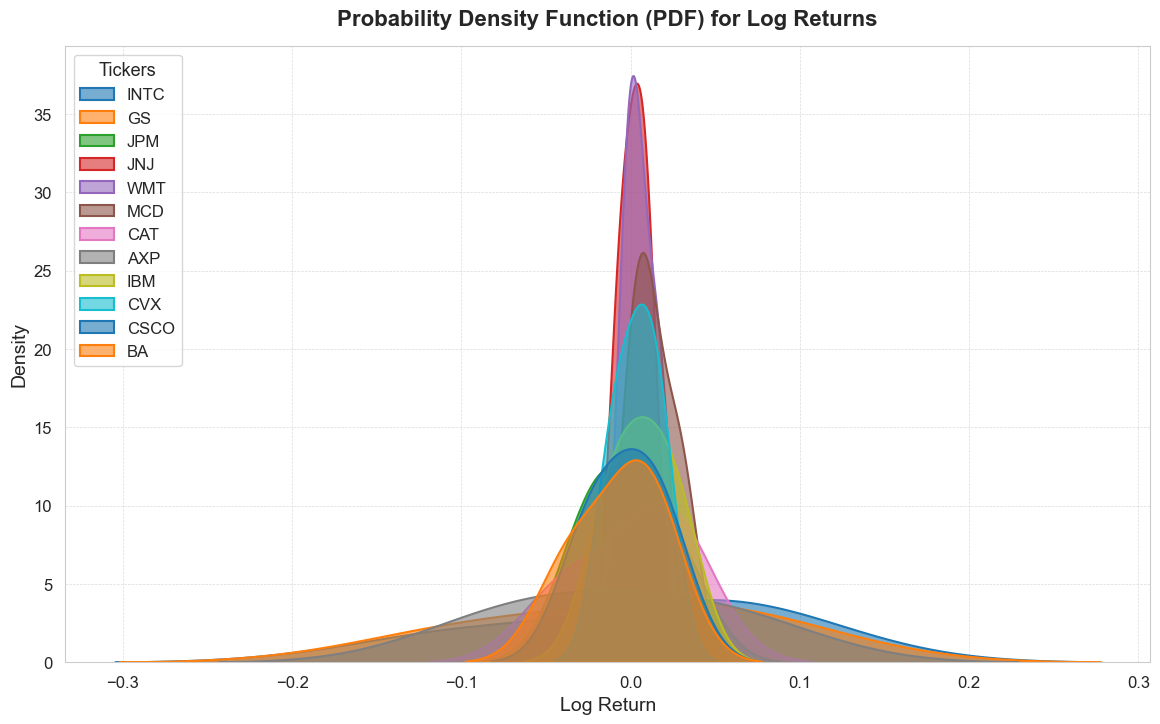

In [83]:
TranscendentalKernel().plot_pdf(bearish_log_returns)


In [84]:
pdf_dict_bearish = {}

for column in bearish_log_returns.columns:
    kde = gaussian_kde(bearish_log_returns[column])

    min_return = bearish_log_returns[column].min()
    max_return = bearish_log_returns[column].max()
    return_range = np.linspace(min_return, max_return, 1000)

    pdf_values = kde(return_range)

    pdf_dict_bearish[column] = {"returns": return_range, "pdf": pdf_values}


In [85]:
def run_simulation():
    simulation = TranscendentalKernel().percentile_to_percentile_mapping(
        37, bearish_log_returns, bearish_vcv, pdf_dict_bearish
    )
    port_return_in_bearish = simulation.sum(axis=1)
    return port_return_in_bearish


port_return_in_bearish = run_simulation()

initial_investment = 50_000_000
start_year = 2024
end_year = 2025
years = list(range(start_year, end_year + 1))

surplus_or_deficit = [0 for _ in years]

if len(port_return_in_bearish) >= 2:
    annual_returns = [port_return_in_bearish[0], port_return_in_bearish[1]]
else:
    annual_returns = [0.05, 0.03]

wealth_at_beginning = [initial_investment]
wealth_at_end = []

for i in range(len(years)):
    wealth_end = wealth_at_beginning[i] * (1 + annual_returns[i]) + surplus_or_deficit[i]
    wealth_at_end.append(wealth_end)
    if i < len(years) - 1:
        wealth_at_beginning.append(wealth_end)

data_bearish = {
    "Year": years,
    "Return (Bearish)": [round(r * 100, 2) for r in annual_returns],
    "Wealth at Beginning": wealth_at_beginning,
    "Wealth at End": wealth_at_end,
}

bearish_case = pd.DataFrame(data_bearish)
display(bearish_case)

print("📉 FIUAM Active Mutual Fund – Bearish Market Scenario")
for i, row in bearish_case.iterrows():
    print(
        f"{int(row['Year'])}: Return = {row['Return (Bearish)']}%, Wealth End = ${row['Wealth at End']:,.2f}"
    )

final_wealth = bearish_case["Wealth at End"].iloc[-1]
total_return = (final_wealth / bearish_case["Wealth at Beginning"].iloc[0]) - 1
print(f"\n🏁 Final Wealth: ${final_wealth:,.2f}")
print(f"💹 Total Return (2024–2025): {total_return*100:.2f}%")


,Year,Return (Bearish),Wealth at Beginning,Wealth at End
0,2024,-8.7500,"50,000,000.0000","45,626,448.2054"
1,2025,-35.2700,"45,626,448.2054","29,533,520.5638"


📉 FIUAM Active Mutual Fund – Bearish Market Scenario
2024: Return = -8.75%, Wealth End = $45,626,448.21
2025: Return = -35.27%, Wealth End = $29,533,520.56

🏁 Final Wealth: $29,533,520.56
💹 Total Return (2024–2025): -40.93%


## Stable Scenario

In [86]:
stable_data = {}
start_date = "2010-01-01"
end_date = "2014-12-31"

for ticker in portfolio.columns:
    print(f"Fetching data for ticker: {ticker}")
    stable_data[ticker] = datafetcher.yfinance_adj_close(ticker, start=start_date, end=end_date)

stable = pd.concat(stable_data.values(), axis=1)
stable.ffill(inplace=True)
stable.bfill(inplace=True)
stable.columns = portfolio.columns
stable = stable.dropna(axis=1)
stable.index = pd.to_datetime(stable.index)
stable


Fetching data for ticker: INTC
Fetching data for ['INTC'] from 2010-01-01 to 2014-12-31 (interval='1d')
Fetching data for ticker: GS
Fetching data for ['GS'] from 2010-01-01 to 2014-12-31 (interval='1d')
Fetching data for ticker: JPM
Fetching data for ['JPM'] from 2010-01-01 to 2014-12-31 (interval='1d')
Fetching data for ticker: JNJ
Fetching data for ['JNJ'] from 2010-01-01 to 2014-12-31 (interval='1d')
Fetching data for ticker: WMT
Fetching data for ['WMT'] from 2010-01-01 to 2014-12-31 (interval='1d')
Fetching data for ticker: MCD
Fetching data for ['MCD'] from 2010-01-01 to 2014-12-31 (interval='1d')
Fetching data for ticker: CAT
Fetching data for ['CAT'] from 2010-01-01 to 2014-12-31 (interval='1d')
Fetching data for ticker: AXP
Fetching data for ['AXP'] from 2010-01-01 to 2014-12-31 (interval='1d')
Fetching data for ticker: IBM
Fetching data for ['IBM'] from 2010-01-01 to 2014-12-31 (interval='1d')
Fetching data for ticker: CVX
Fetching data for ['CVX'] from 2010-01-01 to 2014-12

,INTC,GS,JPM,JNJ,WMT,MCD,CAT,AXP,IBM,CVX,CSCO,BA
Date,,,,,,,,,,,,
2010-01-04,13.5194,130.6416,28.5521,40.4184,12.9868,40.5577,39.2906,32.5555,72.8815,41.6691,16.0612,43.7775
2010-01-05,13.5130,132.9512,29.1052,39.9498,12.8575,40.2476,39.7603,32.4839,72.0011,41.9643,15.9896,45.2113
2010-01-06,13.4676,131.5322,29.2651,40.2747,12.8287,39.6985,39.8811,33.0090,71.5334,41.9695,15.8855,46.5828
2010-01-07,13.3381,134.1061,29.8448,39.9873,12.8359,39.9892,40.0422,33.5443,71.2858,41.8114,15.9571,48.4686
2010-01-08,13.4871,131.5699,29.7715,40.1247,12.7713,39.9505,40.4918,33.5204,72.0011,41.8852,16.0417,48.0010
...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-23,28.7174,157.2505,46.4149,76.7788,23.4724,71.3979,70.5426,80.1497,98.2320,71.0640,20.1365,113.7272
2014-12-24,28.7251,157.5643,46.4149,77.0071,23.4101,71.1024,70.7086,80.3718,97.9777,70.7646,20.1721,114.7855
2014-12-26,28.8095,157.2104,46.4669,77.3531,23.5401,71.8223,71.0934,80.5512,98.2926,70.6274,20.2077,115.1266


In [87]:
stable_log_returns = dataprocessor.return_from_prices(stable, log_returns=True)
stable_log_returns = stable_log_returns.resample("Y").sum() * weights_series
cov_estimator = CovarianceShrinkage(
    stable_log_returns, returns_data=True, delta=optimal_shrinkage_coef
)
stable_vcv = cov_estimator.ledoit_wolf()
stable_vcv


,INTC,GS,JPM,JNJ,WMT,MCD,CAT,AXP,IBM,CVX,CSCO,BA
INTC,0.1476,-0.0211,-0.0109,0.0192,0.0029,0.0102,-0.0155,0.0021,-0.0130,-0.0050,0.0152,0.0095
GS,-0.0211,0.2096,0.0821,0.0180,0.0062,-0.0468,0.0000,0.0281,-0.0238,-0.0095,0.0247,0.0138
JPM,-0.0109,0.0821,0.0774,0.0114,0.0051,-0.0229,-0.0069,0.0175,-0.0104,-0.0039,0.0130,0.0090
JNJ,0.0192,0.0180,0.0114,0.0465,0.0042,-0.0039,-0.0116,0.0104,-0.0043,-0.0008,0.0076,0.0082
WMT,0.0029,0.0062,0.0051,0.0042,0.0391,-0.0036,-0.0089,0.0044,-0.0011,-0.0008,0.0037,0.0018
MCD,0.0102,-0.0468,-0.0229,-0.0039,-0.0036,0.0573,0.0091,-0.0026,0.0080,0.0069,-0.0108,0.0054
CAT,-0.0155,0.0000,-0.0069,-0.0116,-0.0089,0.0091,0.0677,-0.0082,0.0022,0.0034,-0.0114,-0.0007
AXP,0.0021,0.0281,0.0175,0.0104,0.0044,-0.0026,-0.0082,0.0536,-0.0013,0.0029,0.0043,0.0147
IBM,-0.0130,-0.0238,-0.0104,-0.0043,-0.0011,0.0080,0.0022,-0.0013,0.0428,0.0039,-0.0070,0.0003
CVX,-0.0050,-0.0095,-0.0039,-0.0008,-0.0008,0.0069,0.0034,0.0029,0.0039,0.0401,-0.0046,0.0049


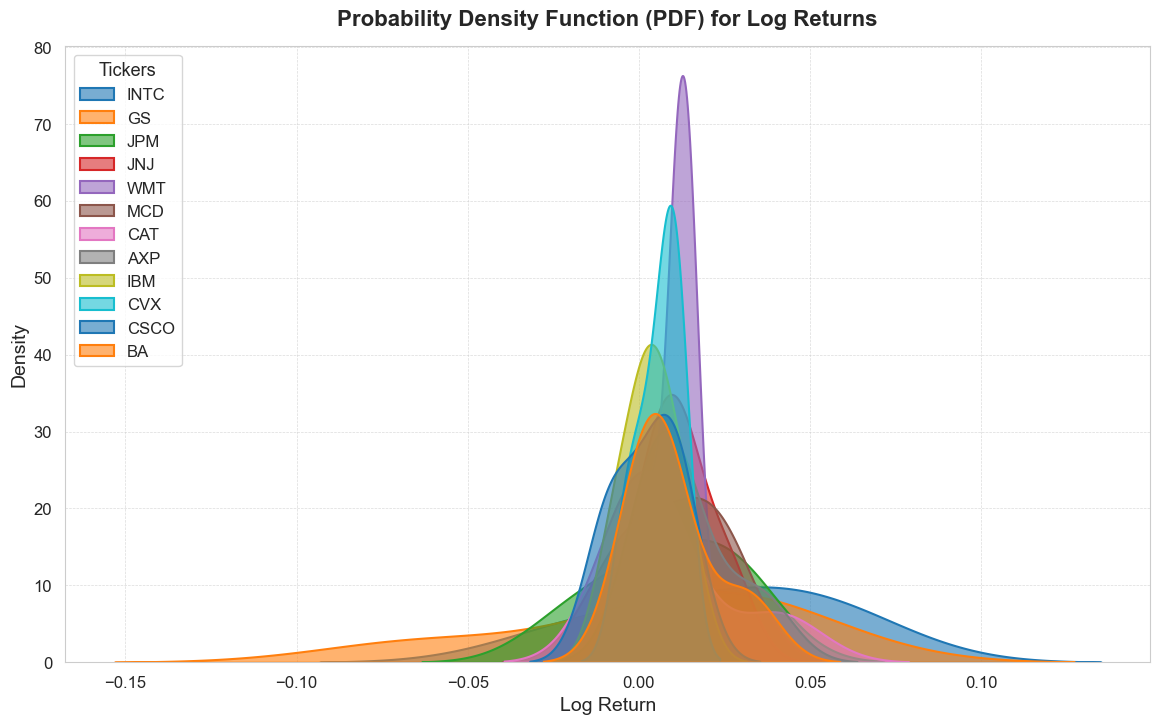

In [88]:
TranscendentalKernel().plot_pdf(stable_log_returns)


In [89]:
pdf_dict_stable = {}

for column in stable_log_returns.columns:
    kde = gaussian_kde(stable_log_returns[column])

    min_return = stable_log_returns[column].min()
    max_return = stable_log_returns[column].max()
    return_range = np.linspace(min_return, max_return, 1000)

    pdf_values = kde(return_range)

    pdf_dict_stable[column] = {"returns": return_range, "pdf": pdf_values}


In [90]:
np.random.seed(42)
simulation = TranscendentalKernel().percentile_to_percentile_mapping(
    37, stable_log_returns, stable_vcv, pdf_dict_stable
)
simulation


,INTC,GS,JPM,JNJ,WMT,MCD,CAT,AXP,IBM,CVX,CSCO,BA
0,0.0631,0.0376,0.0199,-0.0009,0.0015,-0.0086,0.0407,0.0037,-0.0077,-0.0036,0.0138,-0.0006
1,0.0631,0.0376,0.0278,0.0264,0.0148,-0.0086,-0.0012,0.0037,0.0139,0.0103,0.0138,0.0314
2,-0.0213,-0.0636,0.0092,0.0264,0.0015,-0.0086,-0.0012,0.0037,0.0139,0.0103,0.0138,-0.0006
3,0.0631,-0.0636,0.0278,0.0264,0.0148,-0.0086,-0.0012,0.0354,-0.0077,-0.0036,0.0138,-0.0006
4,0.0631,0.0376,0.0278,0.0203,0.0015,0.0264,-0.0012,0.0354,-0.0077,-0.0036,0.0138,0.0314
5,0.0631,-0.0636,0.0278,0.0264,0.0148,0.0015,-0.0012,0.0354,0.0139,-0.0036,-0.0103,0.0314
6,-0.0213,-0.0636,-0.0198,0.0264,0.0148,-0.0086,-0.0012,0.0037,-0.0077,0.0103,0.0138,-0.0006
7,0.0631,-0.0636,-0.0198,-0.0009,0.0015,0.0264,0.0407,0.0037,0.0139,0.0103,0.0138,0.0314
8,-0.0213,0.0376,0.0278,0.0264,0.0093,0.0264,-0.0012,0.0037,-0.0077,0.0103,-0.0103,-0.0006
9,0.0272,-0.0585,0.0278,-0.0009,0.0148,-0.0086,-0.0012,0.0268,0.0139,0.0103,-0.0103,-0.0006


In [91]:
port_return_in_stable = simulation.sum(axis=1)
port_return_in_stable


0     0.1590
1     0.2330
2    -0.0165
3     0.0961
4     0.2449
5     0.1357
6    -0.0538
7     0.1206
8     0.1003
9     0.0407
10    0.2551
11   -0.0631
12    0.1123
13    0.0442
14    0.1130
15    0.1700
16    0.1766
17    0.0399
18    0.1036
19   -0.0415
20    0.0743
21    0.1174
22    0.2378
23    0.1677
24    0.2494
25    0.0424
26    0.1616
27    0.0835
28    0.1656
29    0.0460
30    0.0583
31    0.1677
32    0.0213
33   -0.0338
34    0.1741
35    0.1581
36   -0.0179
dtype: float64

In [92]:
start_year = 2024
end_year = 2025
years = list(range(start_year, end_year + 1))

initial_investment = 50_000_000
initial_wealth = initial_investment
surplus_or_deficit = [0 for _ in years]
port_return_in_stable = port_return_in_stable[: len(years)]

# Initialize lists
wealth_at_beginning = [initial_wealth]
wealth_at_end = []

for i in range(len(years)):
    wealth_end = wealth_at_beginning[i] * (1 + port_return_in_stable[i]) + surplus_or_deficit[i]
    wealth_at_end.append(wealth_end)

    # Append next year's beginning wealth only if not at the last year
    if i < len(years) - 1:
        wealth_at_beginning.append(wealth_end)

# ✅ Ensure all lists are same length
if len(wealth_at_beginning) < len(years):
    wealth_at_beginning.append(wealth_at_end[-1])

data = {
    "Year": years,
    "Return on Portfolio": port_return_in_stable,
    "Wealth at Beginning of Year": wealth_at_beginning,
    "Wealth at End of Year": wealth_at_end,
    "Addition/Drawdown": surplus_or_deficit,
}

stable_case = pd.DataFrame(data)

print("🏦 FIUAM Active Mutual Fund – Stable Market Scenario")
print("------------------------------------------------------")
for i, row in stable_case.iterrows():
    print(
        f"Year {int(row['Year'])}: Return = {row['Return on Portfolio']*100:.2f}%, "
        f"Wealth End = ${row['Wealth at End of Year']:,.2f}"
    )

final_wealth = stable_case["Wealth at End of Year"].iloc[-1]
total_return = (final_wealth / stable_case["Wealth at Beginning of Year"].iloc[0]) - 1
print("------------------------------------------------------")
print(f"🏁 Final Wealth: ${final_wealth:,.2f}")
print(f"💹 Total Return (2024–2025): {total_return*100:.2f}%")

stable_case


🏦 FIUAM Active Mutual Fund – Stable Market Scenario
------------------------------------------------------
Year 2024: Return = 15.90%, Wealth End = $57,947,688.11
Year 2025: Return = 23.30%, Wealth End = $71,451,122.36
------------------------------------------------------
🏁 Final Wealth: $71,451,122.36
💹 Total Return (2024–2025): 42.90%


,Year,Return on Portfolio,Wealth at Beginning of Year,Wealth at End of Year,Addition/Drawdown
0,2024,0.1590,"50,000,000.0000","57,947,688.1132",0
1,2025,0.2330,"57,947,688.1132","71,451,122.3558",0


# Portfolio Evaluation

### Performance

In [93]:
port_data = {}
start_date = "2024-10-01"
end_date = "2025-11-20"

for ticker in portfolio.columns:
    print(f"Fetching data for ticker: {ticker}")
    port_data[ticker] = datafetcher.yfinance_adj_close(ticker, start=start_date, end=end_date)

portfolio_df = pd.concat(port_data.values(), axis=1)
portfolio_df.ffill(inplace=True)
portfolio_df.bfill(inplace=True)
portfolio_df.columns = portfolio.columns


Fetching data for ticker: INTC
Fetching data for ['INTC'] from 2024-10-01 to 2025-11-20 (interval='1d')
Fetching data for ticker: GS
Fetching data for ['GS'] from 2024-10-01 to 2025-11-20 (interval='1d')
Fetching data for ticker: JPM
Fetching data for ['JPM'] from 2024-10-01 to 2025-11-20 (interval='1d')
Fetching data for ticker: JNJ
Fetching data for ['JNJ'] from 2024-10-01 to 2025-11-20 (interval='1d')
Fetching data for ticker: WMT
Fetching data for ['WMT'] from 2024-10-01 to 2025-11-20 (interval='1d')
Fetching data for ticker: MCD
Fetching data for ['MCD'] from 2024-10-01 to 2025-11-20 (interval='1d')
Fetching data for ticker: CAT
Fetching data for ['CAT'] from 2024-10-01 to 2025-11-20 (interval='1d')
Fetching data for ticker: AXP
Fetching data for ['AXP'] from 2024-10-01 to 2025-11-20 (interval='1d')
Fetching data for ticker: IBM
Fetching data for ['IBM'] from 2024-10-01 to 2025-11-20 (interval='1d')
Fetching data for ticker: CVX
Fetching data for ['CVX'] from 2024-10-01 to 2025-11

⏳ Starting Enhanced Style Analysis...
⚠️ 'results[Return]' not found. Using demo returns.
📂 Reading factors: F-F_Research_Data_Factors_daily.xlsx
ℹ️ Factors detected in Percent. Converting to Decimal (/100).

📊 FACTOR ANALYSIS SUMMARY


,Factor,Value,Interpretation
0,Alpha (Daily),0.0012,Excess return not explained by factors
1,Market Beta,0.0668,Sensitivity to overall market (>1: Aggressive)
2,Size (SMB),0.0655,"+: Small Cap, -: Large Cap"
3,Value (HML),0.0457,"+: Value, -: Growth"
4,R-Squared,0.0052,% of variance explained by model


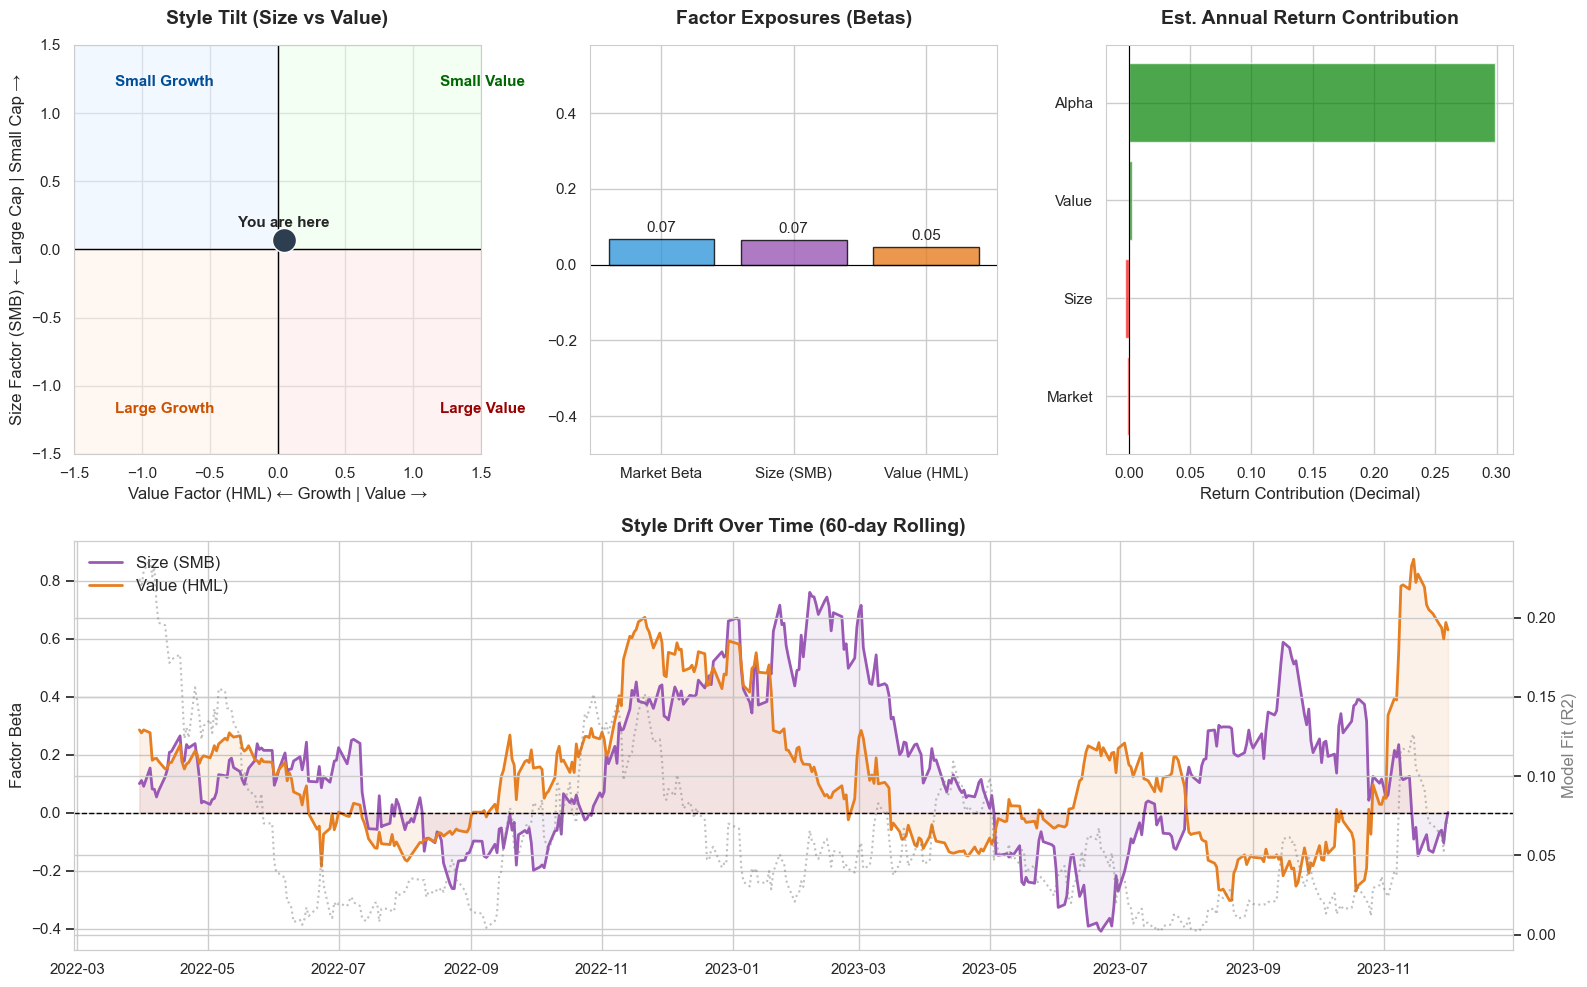

In [94]:
print("⏳ Starting Enhanced Style Analysis...")
try:
    port_rets = None

    # Always define demo dates
    dates_demo = pd.date_range("2022-01-01", periods=500, freq="B")

    # Try to load real portfolio returns
    if "results" in locals() and isinstance(results, pd.DataFrame) and "Return" in results.columns:
        port_rets = results["Return"].copy()
        print("✅ Loaded Portfolio Return from 'results'.")
    else:
        print("⚠️ 'results[Return]' not found. Using demo returns.")

        np.random.seed(42)
        mkt = np.random.normal(0.0005, 0.01, len(dates_demo))
        smb = np.random.normal(0.0002, 0.005, len(dates_demo))
        hml = np.random.normal(0.0001, 0.005, len(dates_demo))
        noise = np.random.normal(0, 0.002, len(dates_demo))
        demo_rets = (1.1 * mkt) + (0.6 * smb) + (0.4 * hml) + noise
        port_rets = pd.Series(demo_rets, index=dates_demo)

    ff_file = "F-F_Research_Data_Factors_daily.xlsx"

    sa = StyleAnalytics(port_rets, ff_file)
    stats = sa.run_regression()

    summary_df = pd.DataFrame(
        {
            "Factor": ["Alpha (Daily)", "Market Beta", "Size (SMB)", "Value (HML)", "R-Squared"],
            "Value": [
                stats["Alpha"],
                stats["Beta_Market"],
                stats["Beta_Size (SMB)"],
                stats["Beta_Value (HML)"],
                stats["R_Squared"],
            ],
            "Interpretation": [
                "Excess return not explained by factors",
                "Sensitivity to overall market (>1: Aggressive)",
                "+: Small Cap, -: Large Cap",
                "+: Value, -: Growth",
                "% of variance explained by model",
            ],
        }
    )

    print("\n" + "=" * 60)
    print("📊 FACTOR ANALYSIS SUMMARY")
    print("=" * 60)
    display(
        summary_df.style.format({"Value": "{:.4f}"}).background_gradient(
            cmap="Blues", subset=["Value"]
        )
    )
    sa.plot_dashboard()

except Exception:
    print("\n❌ ERROR DETAILS:")
    traceback.print_exc()
    print("\n💡 HINT: Ensure 'F-F_Research_Data_Factors_daily.xlsx' is in the folder.")


In [95]:
initial_investment = 50_000_000
num_of_shares = initial_investment / portfolio_df.iloc[-1]
num_of_shares.round()


INTC   1,424,096.0000
GS        63,929.0000
JPM      164,870.0000
JNJ      248,469.0000
WMT      496,968.0000
MCD      166,149.0000
CAT       90,398.0000
AXP      145,079.0000
IBM      173,292.0000
CVX      329,598.0000
CSCO     637,836.0000
BA       269,251.0000
Name: 2025-11-19 00:00:00, dtype: float64

In [96]:
returns_df = portfolio_df.pct_change().dropna()
port_retss = returns_df.sum(axis=1)


In [97]:
PortfolioPerformance().plot_portfolio_returns(port_retss.cumsum())


In [98]:
from utils import PortfolioVisualizer

PortfolioVisualizer()

cumulative_returns_df = (1 + returns_df).prod() - 1
PortfolioVisualizer().plot_bar_returns(cumulative_returns_df)


In [99]:
(cumulative_returns_df * 100).round(2)  # cum returns


INTC   54.7400
GS     63.6200
JPM    50.5000
JNJ    29.0600
WMT    25.0000
MCD     2.2500
CAT    43.6000
AXP    30.0300
IBM    36.0000
CVX     7.1200
CSCO   53.6300
BA     20.4100
dtype: float64

In [100]:
(cumulative_returns_df * stock_weights) * 100  # weighted returns


INTC   9.1189
GS     6.6421
JPM    4.4922
JNJ    2.5815
WMT    2.2216
MCD    0.2002
CAT    3.5835
AXP    2.2647
IBM    2.0671
CVX    0.3951
CSCO   2.7817
BA     1.0428
dtype: float64

In [101]:
ticker = "^IRX"

start_date = "2023-01-01"
end_date = "2025-11-20"

rf = yf.download(ticker, start=start_date, end=end_date)
rf = rf[["Close"]]
rf = rf.rename(columns={"Close": "rf"})
rolling_rf = rf.rolling(window=252).mean()
rolling_rf.tail()


[*********************100%***********************]  1 of 1 completed


Price,rf
Ticker,^IRX
Date,
2025-11-13,4.1393
2025-11-14,4.1368
2025-11-17,4.1343
2025-11-18,4.1319
2025-11-19,4.1295


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Portfolio Performance Metrics:
Annualized Sharpe Ratio: 1.40
Annualized Jensen's Alpha (iShares Global Tech ETF): 0.15
Annualized Jensen's Alpha (iShares MSCI Emerging Markets ETF): 0.17
Annualized Jensen's Alpha (iShares Global Clean Energy ETF): 0.24


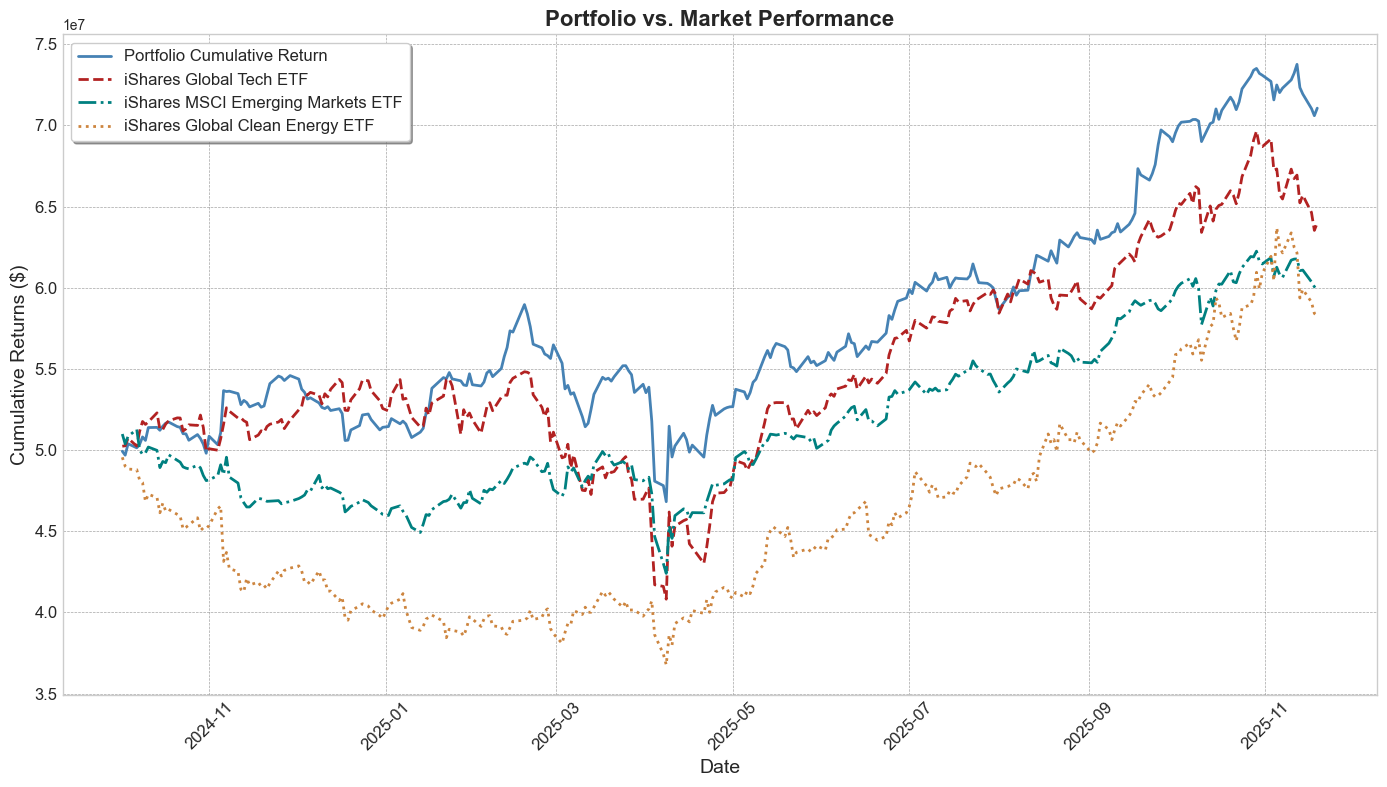

In [102]:
start_date = "2024-10-01"
end_date = "2025-11-20"

ixn = yf.download("IXN", start=start_date, end=end_date)["Close"]
msci_etf = yf.download("EEM", start=start_date, end=end_date)["Close"]
global_clean_energy_index = yf.download("ICLN", start=start_date, end=end_date)["Close"]

port_retss = (portfolio_df.pct_change() @ stock_weights).dropna()  # Weighted daily returns

initial_money = 50000000
trading_days_per_year = 252
risk_free_rate_annual = (rolling_rf.iloc[-1].values) / 100

portfolio_cum_returns = (1 + port_retss).cumprod() * initial_money

ixn_returns = ixn.pct_change().dropna()
msci_returns = msci_etf.pct_change().dropna()
global_clean_energy_returns = global_clean_energy_index.pct_change().dropna()

risk_free_rate_daily = risk_free_rate_annual / trading_days_per_year
excess_returns = port_retss - risk_free_rate_daily
sharpe_ratio = (excess_returns.mean() * trading_days_per_year) / (
    port_retss.std() * np.sqrt(trading_days_per_year)
)

excess_spdr = ixn_returns - risk_free_rate_daily
excess_msci = msci_returns - risk_free_rate_daily
excess_global_clean_energy = global_clean_energy_returns - risk_free_rate_daily

# Ensure the data shares the same index (time axis)
ixn_returns, excess_returns = ixn_returns.align(excess_returns, join="inner", axis=0)
msci_returns, excess_returns = msci_returns.align(excess_returns, join="inner", axis=0)
global_clean_energy_returns, excess_returns = global_clean_energy_returns.align(
    excess_returns, join="inner", axis=0
)

# Flatten the data to make sure it is 1D
slope_spdr, intercept_spdr, _, _, _ = linregress(
    ixn_returns.values.flatten(), excess_returns.values.flatten()
)
slope_msci, intercept_msci, _, _, _ = linregress(
    msci_returns.values.flatten(), excess_returns.values.flatten()
)
slope_global_clean_energy, intercept_global_clean_energy, _, _, _ = linregress(
    global_clean_energy_returns.values.flatten(), excess_returns.values.flatten()
)


jensen_alpha_daily_spdr = intercept_spdr
jensen_alpha_daily_msci = intercept_msci
jensen_alpha_daily_global_clean_energy = intercept_global_clean_energy

jensen_alpha_daily_spdr = jensen_alpha_daily_spdr * trading_days_per_year
jensen_alpha_daily_msci = jensen_alpha_daily_msci * trading_days_per_year
jensen_alpha_daily_global_clean_energy = (
    jensen_alpha_daily_global_clean_energy * trading_days_per_year
)

# Display Results
print("Portfolio Performance Metrics:")
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Annualized Jensen's Alpha (iShares Global Tech ETF): {jensen_alpha_daily_spdr:.2f}")
print(
    f"Annualized Jensen's Alpha (iShares MSCI Emerging Markets ETF): {jensen_alpha_daily_msci:.2f}"
)
print(
    f"Annualized Jensen's Alpha (iShares Global Clean Energy ETF): {jensen_alpha_daily_global_clean_energy:.2f}"
)

PortfolioPerformance().plot_performance(
    portfolio_cum_returns, ixn_returns, msci_returns, global_clean_energy_returns, initial_money
)


In [103]:
sixn_returns = ixn_returns.squeeze()
msci_returns = msci_returns.squeeze()
global_clean_energy_returns = global_clean_energy_returns.squeeze()

if isinstance(port_retss, pd.DataFrame):
    port_retss = port_retss.squeeze()

common_index = ixn_returns.index.intersection(port_retss.index)
ixn_returns = ixn_returns.loc[common_index]
msci_returns = msci_returns.loc[common_index]
global_clean_energy_returns = global_clean_energy_returns.loc[common_index]
port_retss = port_retss.loc[common_index]

print(ixn_returns.shape, port_retss.shape)

beta_spdr, _, _, _, _ = linregress(ixn_returns.values.flatten(), port_retss.values.flatten())
beta_msci, _, _, _, _ = linregress(msci_returns.values.flatten(), port_retss.values.flatten())
beta_global_clean_energy, _, _, _, _ = linregress(
    global_clean_energy_returns.values.flatten(), port_retss.values.flatten()
)

print(f"Beta (iShares Global Tech ETF): {beta_spdr:.2f}")
print(f"Beta (iShares MSCI Emerging Markets ETF): {beta_msci:.2f}")
print(f"Beta (iShares Global Clean Energy ETF): {beta_global_clean_energy:.2f}")


(285, 1) (285,)
Beta (iShares Global Tech ETF): 0.57
Beta (iShares MSCI Emerging Markets ETF): 0.69
Beta (iShares Global Clean Energy ETF): 0.30


In [104]:
"""rolling_max = portfolio_cum_returns.cummax()
drawdown = (portfolio_cum_returns - rolling_max) / rolling_max
max_drawdown = drawdown.min()
print(f"Maximum Drawdown: {max_drawdown:.2%}")"""


'rolling_max = portfolio_cum_returns.cummax()\ndrawdown = (portfolio_cum_returns - rolling_max) / rolling_max\nmax_drawdown = drawdown.min()\nprint(f"Maximum Drawdown: {max_drawdown:.2%}")'

In [105]:
"""rf_annual = 0.03
rf_daily = (1 + rf_annual)**(1/252) - 1
excess_returns = port_retss - rf_daily
returns = pd.to_numeric(excess_returns.squeeze() if hasattr(excess_returns, "squeeze") else excess_returns,
                               errors="coerce").dropna()

sharpe_daily = excess_returns.mean() / excess_returns.std(ddof=1)
sharpe_annual = sharpe_daily * np.sqrt(252)

print(f"Sharpe Ratio (Daily): {sharpe_daily:.2f}")
print(f"Sharpe Ratio (Annualized): {sharpe_annual:.2f}")"""


'rf_annual = 0.03  \nrf_daily = (1 + rf_annual)**(1/252) - 1\nexcess_returns = port_retss - rf_daily\nreturns = pd.to_numeric(excess_returns.squeeze() if hasattr(excess_returns, "squeeze") else excess_returns,\n                               errors="coerce").dropna()\n\nsharpe_daily = excess_returns.mean() / excess_returns.std(ddof=1)\nsharpe_annual = sharpe_daily * np.sqrt(252)\n\nprint(f"Sharpe Ratio (Daily): {sharpe_daily:.2f}")\nprint(f"Sharpe Ratio (Annualized): {sharpe_annual:.2f}")'

In [106]:
"""downside_returns = port_retss[port_retss < 0]
sortino_ratio = excess_returns.mean() / downside_returns.std()
print(f"Sortino Ratio: {sortino_ratio:.2f}")"""


'downside_returns = port_retss[port_retss < 0]\nsortino_ratio = excess_returns.mean() / downside_returns.std()\nprint(f"Sortino Ratio: {sortino_ratio:.2f}")'

In [107]:
"""annualized_return = (portfolio_cum_returns.iloc[-1] / portfolio_cum_returns.iloc[0]) ** (252 / len(port_retss)) - 1
print(f"Annualized Return: {annualized_return:.2%}")"""


'annualized_return = (portfolio_cum_returns.iloc[-1] / portfolio_cum_returns.iloc[0]) ** (252 / len(port_retss)) - 1\nprint(f"Annualized Return: {annualized_return:.2%}")'

In [108]:
port_series = port_retss.squeeze() if isinstance(port_retss, pd.DataFrame) else port_retss
ixn_series = ixn_returns.squeeze() if isinstance(ixn_returns, pd.DataFrame) else ixn_returns
msci_series = msci_returns.squeeze() if isinstance(msci_returns, pd.DataFrame) else msci_returns
icln_series = (
    global_clean_energy_returns.squeeze()
    if isinstance(global_clean_energy_returns, pd.DataFrame)
    else global_clean_energy_returns
)

port_series = pd.to_numeric(port_series, errors="coerce")
ixn_series = pd.to_numeric(ixn_series, errors="coerce")
msci_series = pd.to_numeric(msci_series, errors="coerce")
icln_series = pd.to_numeric(icln_series, errors="coerce")

aligned_ixn, aligned_port_ixn = ixn_series.align(port_series, join="inner", axis=0)
aligned_msci, aligned_port_msci = msci_series.align(port_series, join="inner", axis=0)
aligned_icln, aligned_port_icln = icln_series.align(port_series, join="inner", axis=0)

corr_spdr = aligned_port_ixn.corr(aligned_ixn)
corr_msci = aligned_port_msci.corr(aligned_msci)
corr_icln = aligned_port_icln.corr(aligned_icln)

print(f"Correlation with iShares Global Tech ETF (IXN): {corr_spdr:.2f}")
print(f"Correlation with iShares MSCI Emerging Markets ETF (EEM): {corr_msci:.2f}")
print(f"Correlation with iShares Global Clean Energy ETF (ICLN): {corr_icln:.2f}")


Correlation with iShares Global Tech ETF (IXN): 0.72
Correlation with iShares MSCI Emerging Markets ETF (EEM): 0.59
Correlation with iShares Global Clean Energy ETF (ICLN): 0.34


In [109]:
portfolio_volatility = port_retss.std() * (252**0.5)  # Annualized volatility
print(f"Portfolio Volatility: {portfolio_volatility:.2%}")


Portfolio Volatility: 20.86%


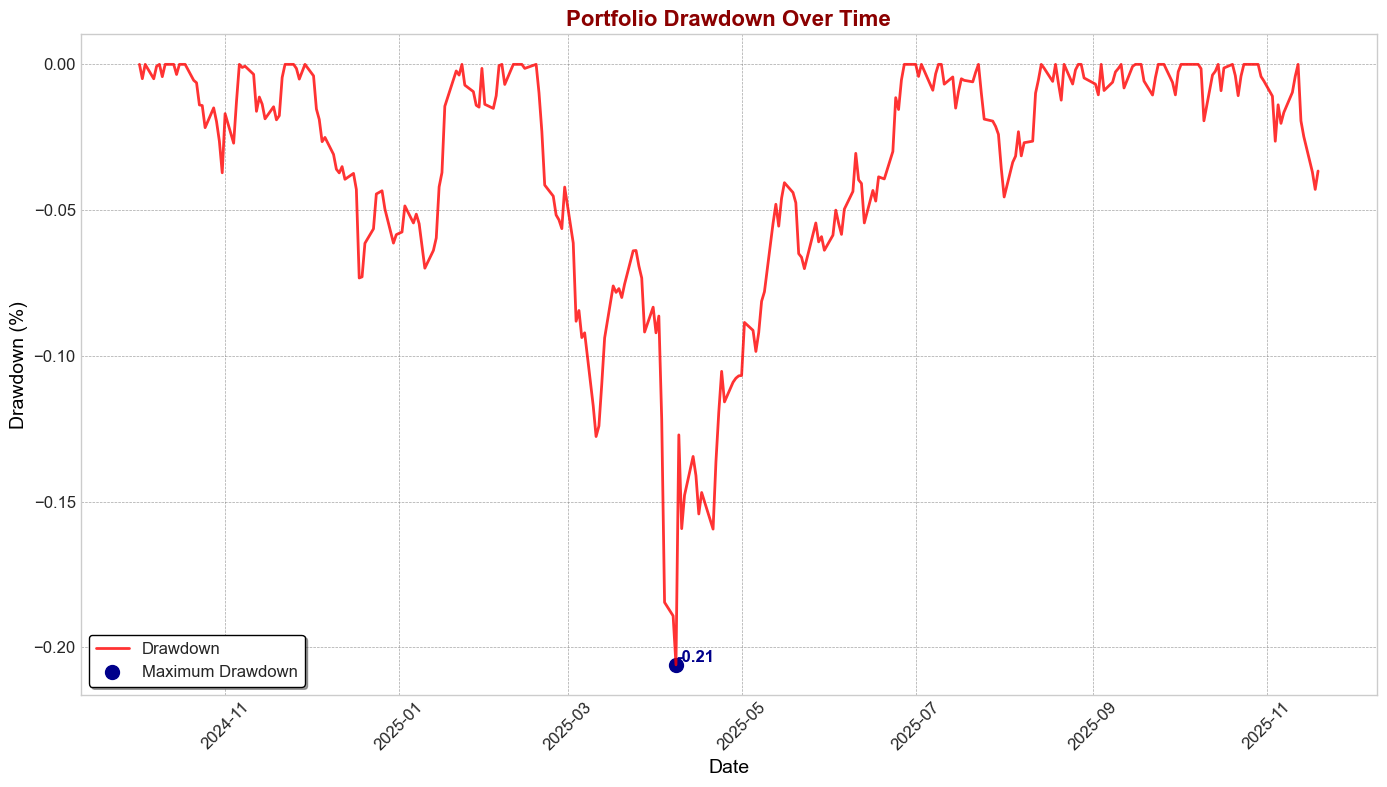

In [110]:
# portfolio_cum_returns: Series (NAV) của bạn
rolling_max = portfolio_cum_returns.cummax()
dd_series = (portfolio_cum_returns - rolling_max) / rolling_max  # dd_series là số

PortfolioPerformance().plot_mdd(dd_series)


🔄 Fetching data from 2024-10-01 to 2025-11-20...
✅ Data aligned. Total trading days analyzed: 285


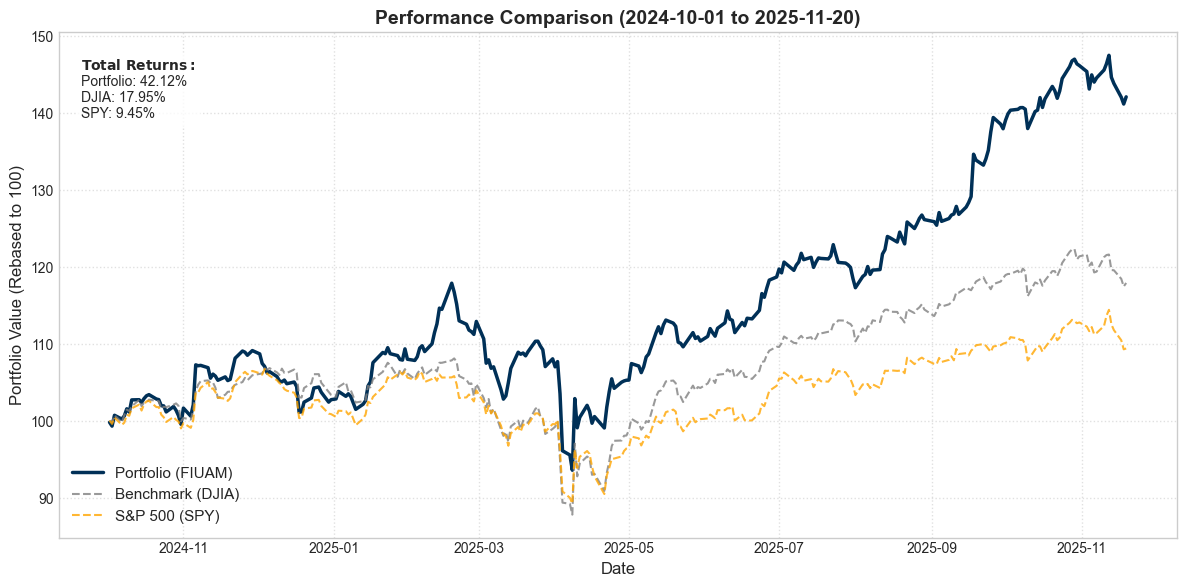


📊 Detailed Performance Metrics:


,Total Return,Ann. Return (CAGR),Ann. Volatility,Sharpe Ratio,Max Drawdown
Portfolio,42.12%,36.45%,20.86%,1.60,-20.59%
DJIA,17.95%,15.72%,18.86%,0.67,-18.76%
SPY,9.45%,8.31%,16.45%,0.32,-16.37%


In [112]:
if "final_weights" in locals():
    START = "2024-10-01"
    END = "2025-11-20"

    final_stats = analyze_portfolio_vs_benchmark_specific_period(final_weights, START, END)
else:
    print("❌ Error: 'final_weights' not found. Please run the Portfolio Optimization cell first.")


# Passive Fund Management

🔄 Retrieving market data for period: 2024-10-01 to 2025-11-20...
✅ Data ready. Loaded 32 historical tickers (Portfolio will hold exactly 30).

🚀 Initializing Portfolio Simulation...
   📅 Start Date: 2024-10-01
   💼 Initial Holdings: 30 stocks (Checking: INTC in, NVDA out)
   ⚖️  [EVENT 2024-11-08] Rebalancing Portfolio...
       -> Selling: INTC, DOW
       -> Buying:  NVDA, SHW
       -> New Holdings Count: 30 stocks (Correct)
🏁 Simulation Completed.

 PERFORMANCE REPORT
Ending Value:    $55,795,043.01
Total Return:    11.59%
Volatility:      16.45%
Sharpe Ratio:    0.43
Tracking Error:  0.22% (Target < 5%)


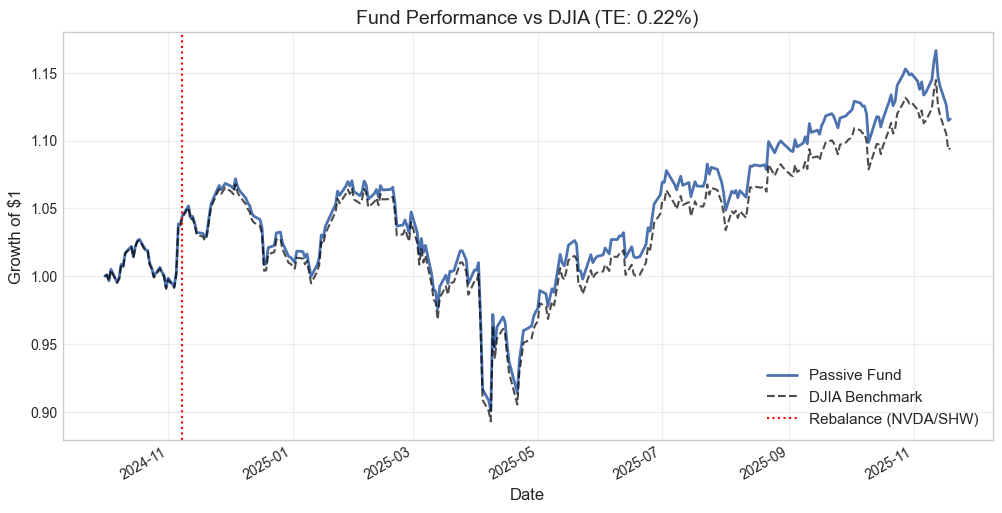

In [113]:
# Initialize the manager for the specific investment window
fund = PassiveFundManager(start_date="2024-10-01", end_date="2025-11-20")

# Execute the process
fund.track_performance()
fund.evaluate_and_plot()


In [114]:
fund = PassiveFundManager(start_date="2024-10-01", end_date="2025-11-20")
print("\n--- FINAL VERIFICATION ---")
fund.track_performance()
fund.analyze_rebalancing("2025-11-08")



--- FINAL VERIFICATION ---
🔄 Retrieving market data for period: 2024-10-01 to 2025-11-20...
✅ Data ready. Loaded 32 historical tickers (Portfolio will hold exactly 30).

🚀 Initializing Portfolio Simulation...
   📅 Start Date: 2024-10-01
   💼 Initial Holdings: 30 stocks (Checking: INTC in, NVDA out)
   ⚖️  [EVENT 2024-11-08] Rebalancing Portfolio...
       -> Selling: INTC, DOW
       -> Buying:  NVDA, SHW
       -> New Holdings Count: 30 stocks (Correct)
🏁 Simulation Completed.

📊 CHECKING PORTFOLIO AT: 2025-11-08
   👉 TOTAL STOCKS HELD: 30 (Should be 30)
   --- Checking Specific Pairs ---
   ✅ NVDA: HELD (Val: $1,403,231)
   ✅ INTC: REMOVED
   ✅ SHW : HELD (Val: $2,531,155)
   ✅ DOW : REMOVED


🔄 Retrieving market data for period: 2024-10-01 to 2025-11-20...
✅ Data ready. Loaded 32 historical tickers (Portfolio will hold exactly 30).

🚀 Initializing Portfolio Simulation...
   📅 Start Date: 2024-10-01
   💼 Initial Holdings: 30 stocks (Checking: INTC in, NVDA out)
   ⚖️  [EVENT 2024-11-08] Rebalancing Portfolio...
       -> Selling: INTC, DOW
       -> Buying:  NVDA, SHW
       -> New Holdings Count: 30 stocks (Correct)
🏁 Simulation Completed.
 📊 FUND PERFORMANCE & RISK REPORT
Investment Period:      2024-10-01 to 2025-11-20
Ending Value:           $55,795,043.01
Total Return:           11.59%
Sharpe Ratio:           0.52
--------------------------------------------------------------------------------
 🛡️  HEDGE SETUP (AT INCEPTION)
Execution Date:         2024-10-01
Equity Exposure (95%):  $47,500,000.00 (Target for Hedging)
Futures Price (Start):  42,157
Contracts Required:     225.35 (SHORT)
Recommendation:         Sell 225 DJIA Futures to stay Market Neutral.

Displaying Vi

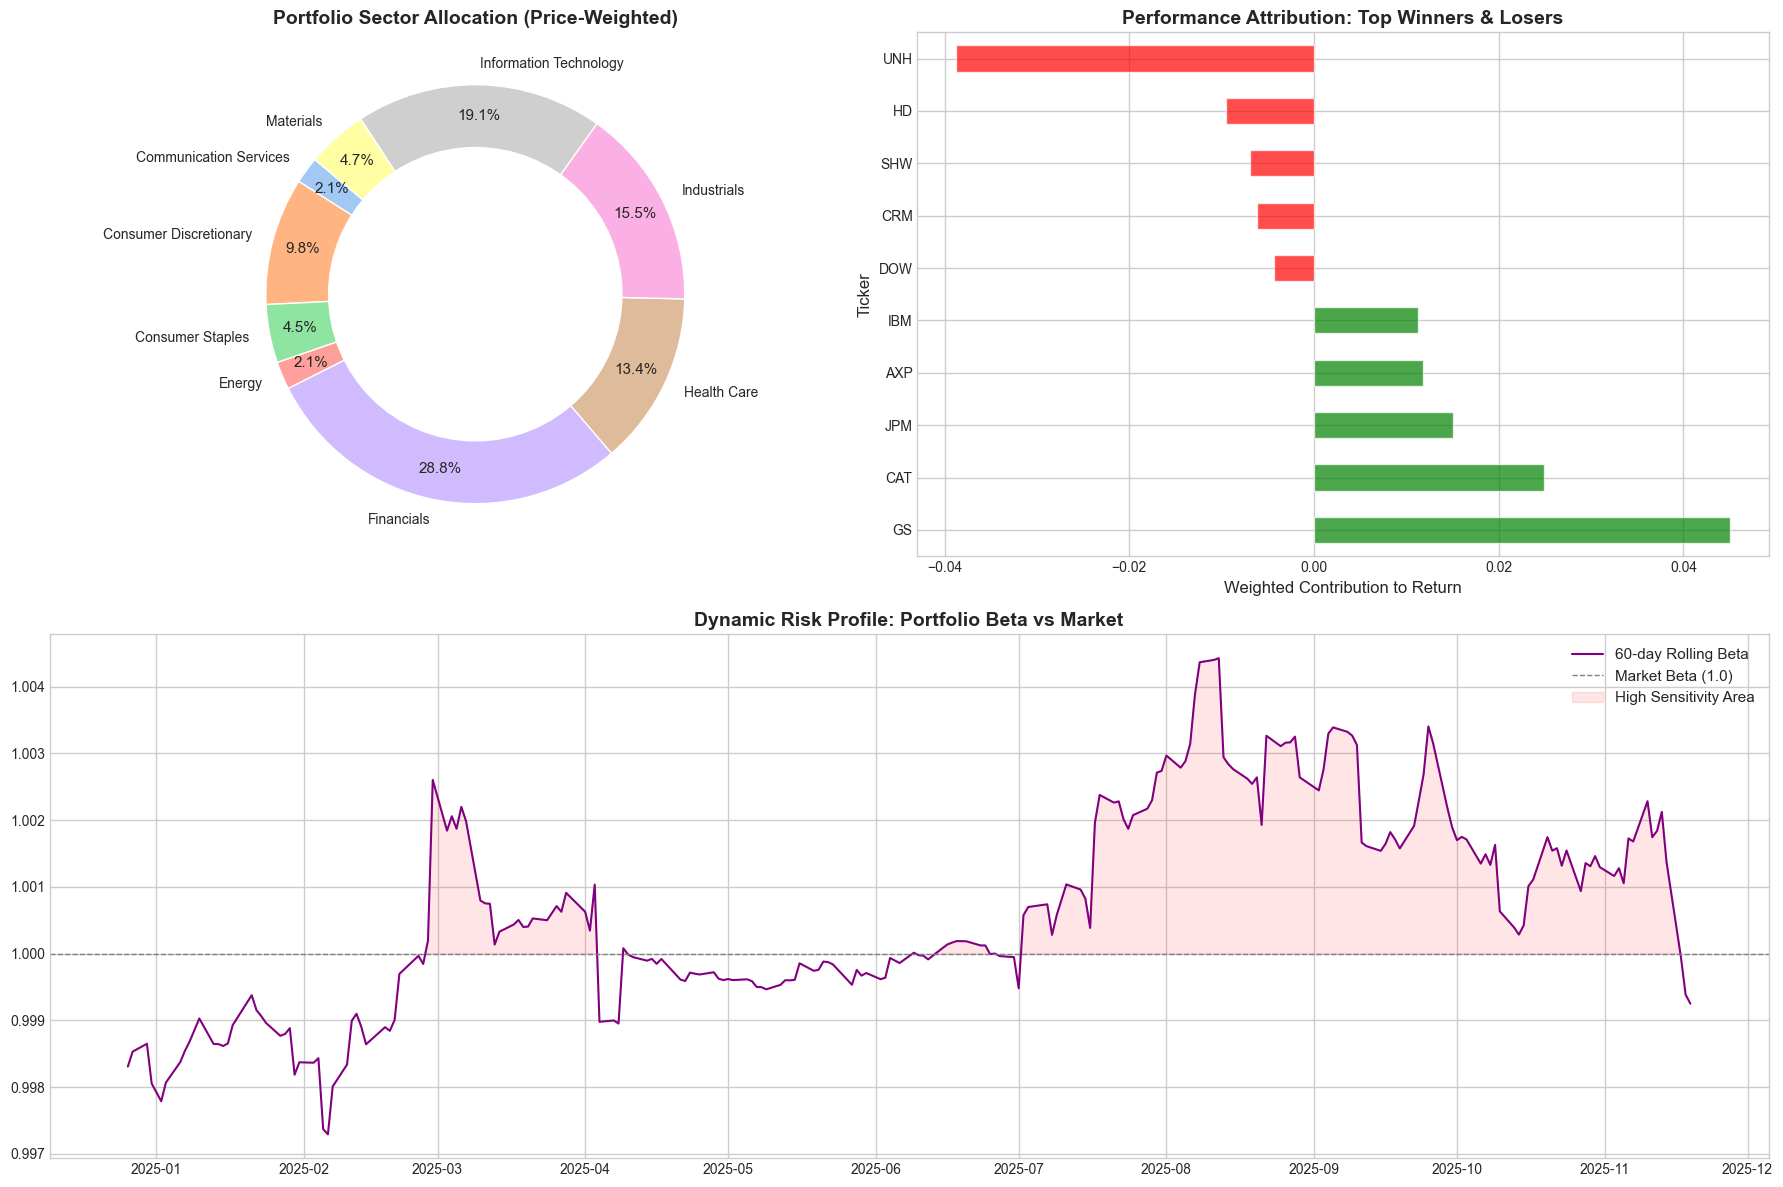

In [115]:
adv_fund = AdvancedPassiveManager(start_date="2024-10-01", end_date="2025-11-20")
adv_fund.fetch_market_data()
adv_fund.generate_dashboard()


In [116]:
explain_hedging_logic(adv_fund)



 🛡️  HEDGING STRATEGY EXPLANATION (SHORT FUTURES HEDGE)
1. CAPITAL STRUCTURE & ALLOCATION (Oct 2024):
   • Total Portfolio AUM:    $50,000,000.00
   • Cash/Margin (5%):       $2,500,000.00 (Reserved for Long Futures Exposure)
   • Equity Portfolio (95%): $47,500,000.00
     (We are hedging this $47.5M against market downside)

2. HEDGE CALCULATION (At Start Date: 2024-10-01):
   • DJIA Index Level:       42,156.97
   • Futures Multiplier:     $5 (E-mini DJIA)
   • Notional per Contract:  $210,784.84
   ------------------------------------------------------------
   • Calculation:            $47,500,000 / $210,784.84
   • Theoretical Short:      225.35 contracts

3. EXECUTION STRATEGY:
   👉 SELL 225 CONTRACTS of DJIA Futures (Short Position).
   Rationale: This locks in the value of the $47.5M equity portfolio.
   The remaining 5% cash is used separately for the active strategy.




 📉 SIMULATING HEDGED PERFORMANCE (MARKET NEUTRAL)
Strategy Structure:
   • Long Equity (Start):  $47,500,000.00 (95%)
   • Cash Reserve:         $2,500,000.00 (5%)
   • Short Hedge:          Fully hedging the $47.5M Equity exposure.

Results (2024-10-01 - 2025-11-20):
   • Unhedged Return:      11.59%
   • Hedged Return (Alpha):2.04%
   • Hedged Volatility:    0.27%
   ✅ SUCCESS: The portfolio generated positive Alpha (2.04%) independent of market moves.


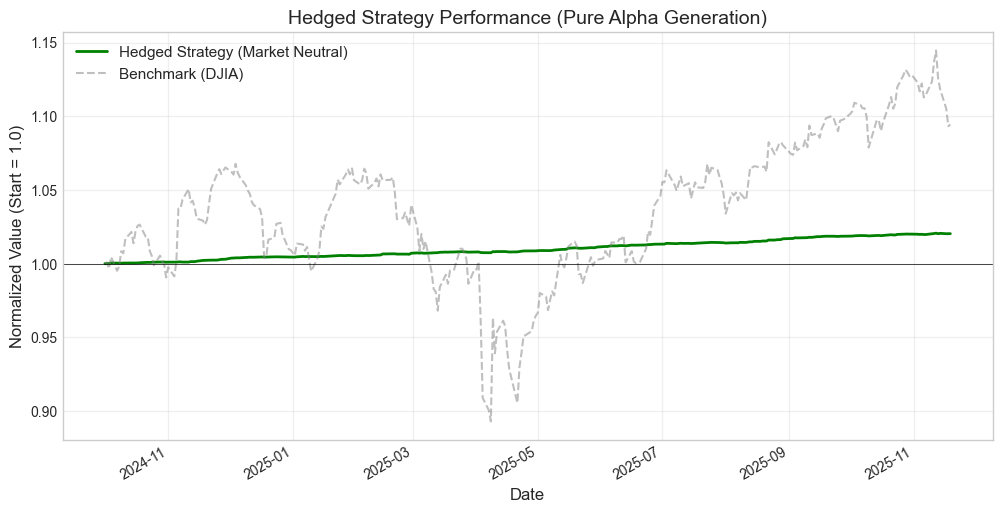

Date
2024-10-01   50,000,000.0000
2024-10-02   50,004,967.0045
2024-10-03   50,004,682.2654
2024-10-04   50,022,878.6041
2024-10-07   50,019,409.0405
                   ...      
2025-11-13   51,017,136.5506
2025-11-14   51,029,412.3079
2025-11-17   51,016,716.3485
2025-11-18   51,017,807.9800
2025-11-19   51,018,831.2640
Length: 286, dtype: float64

In [117]:
simulate_hedged_performance(adv_fund)



💰 CASH EQUITIZATION SIMULATION (Assuming 5.0% Cash Level)
1️⃣ SITUATION ANALYSIS:
   - Total NAV (Begin):       $50,000,000.00
   - Idle Cash (Begin):       $2,500,000.00 (5.0%)
   - DJIA Level (Begin):      42,196.52  | Date: 2024-10-02
------------------------------------------------------------
2️⃣ EXECUTION (LONG FUTURES):
   - Contract Value ($10x): $421,965.20
   - Contracts Needed:        5.9247
   👉 RECOMMENDATION:         LONG 6 DJIA Futures Contracts
------------------------------------------------------------
3️⃣ IMPACT ON TRACKING ERROR (The Philosophy):
   ❌ Scenario A (Hold Cash):    Tracking Error = 0.8226%
   ✅ Scenario B (Equitized):    Tracking Error = 0.0000% (Minimized!)


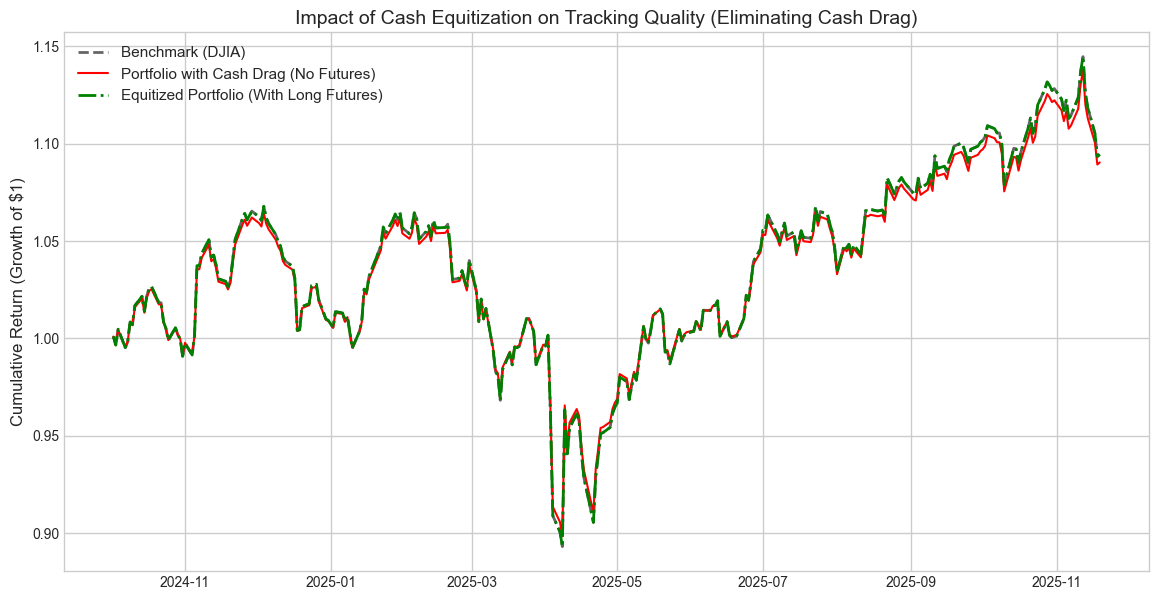

In [118]:
# LONG FUTURES CONTRACT FOR HEDGING


cash_manager = CashEquitizationManager(adv_fund)
r_drag, r_eq, cash_amt = cash_manager.simulate_cash_drag_vs_equitization(cash_weight=0.05)
cash_manager.plot_comparison(r_drag, r_eq)


In [119]:
# Calculate each stock's contribution (Attribution)
# Contribution = Average weight * Total stock return
stock_returns = (fund.stock_data.iloc[-1] - fund.stock_data.iloc[0]) / fund.stock_data.iloc[0]
avg_weights = (
    fund.stock_data.iloc[0] / fund.stock_data.iloc[0].sum()
)  # Use initial weights as a proxy
contribution = stock_returns * avg_weights

print("TOP 5 STOCKS CONTRIBUTING TO GROWTH (ATTRIBUTION):")
print(contribution.sort_values(ascending=False).head(5).apply(lambda x: f"{x:.2%}"))


TOP 5 STOCKS CONTRIBUTING TO GROWTH (ATTRIBUTION):
Ticker
GS     4.50%
CAT    2.49%
JPM    1.51%
AXP    1.18%
IBM    1.13%
dtype: object



📊 Generating Sector Allocation Chart...


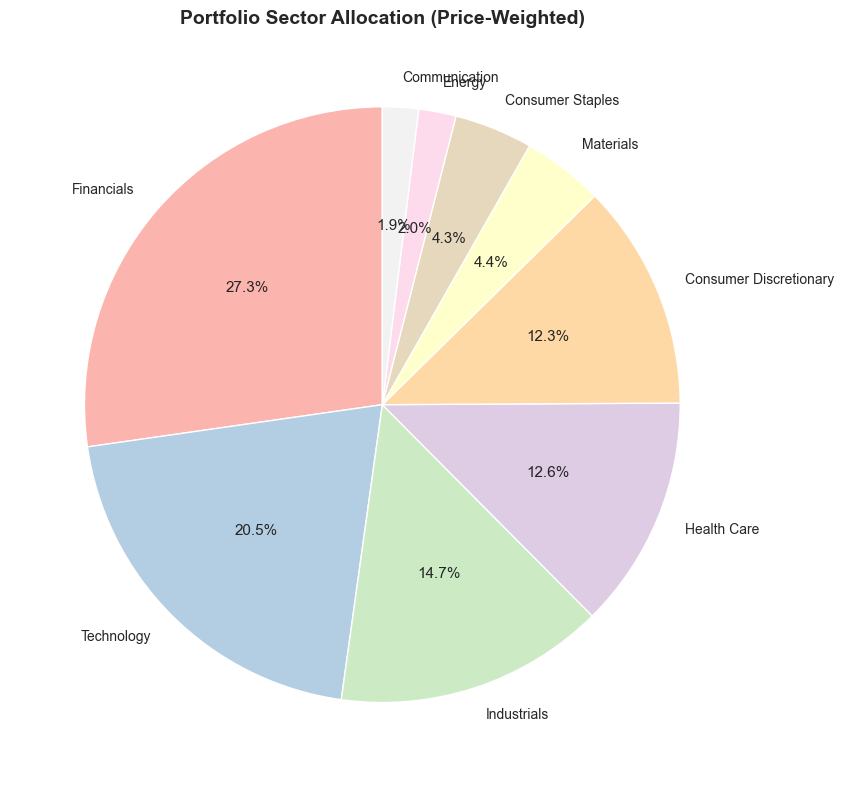


--- Sector Allocation Details (Sector Weights) ---
Financials                27.26%
Technology                20.53%
Industrials               14.65%
Health Care               12.64%
Consumer Discretionary    12.27%
Materials                  4.41%
Consumer Staples           4.25%
Energy                     2.03%
Communication              1.95%
dtype: object

📉 Generating Drawdown Analysis Chart...


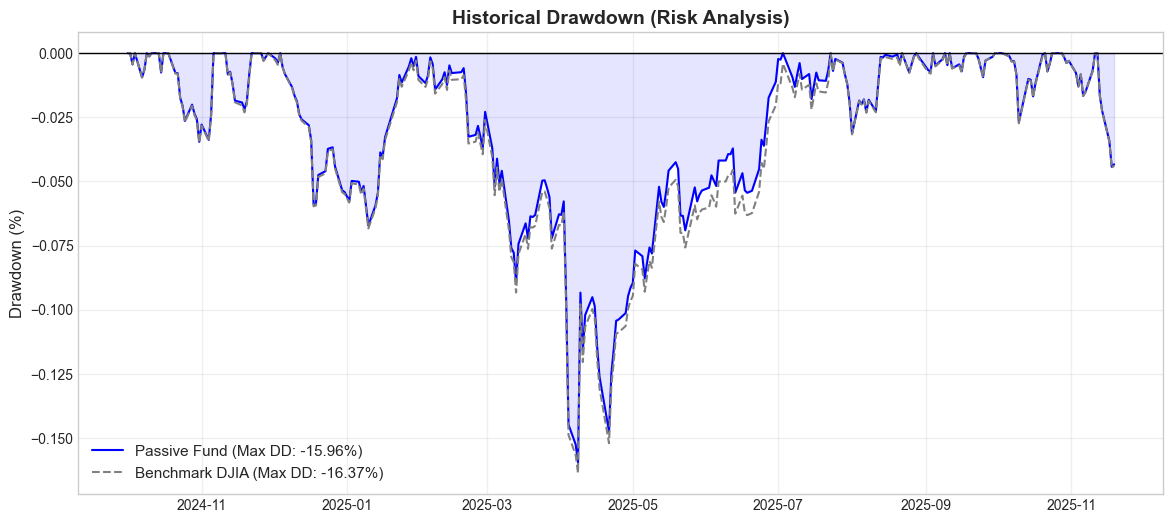

In [120]:
viz = FundVisualizer(adv_fund)
viz.plot_sector_allocation()
viz.plot_drawdown()


In [129]:
fund = PassiveFundManager(start_date="2024-10-01", end_date="2025-11-20")
fund.track_performance()
# fund.fetch_market_data()

nav_hedged, metrics, dd = hedged_long_futures_nav_and_metrics(
    fund, cash_weight=0.05, rf_annual=0.04
)

print(pd.Series(metrics).apply(lambda x: f"{x:.4%}" if isinstance(x, float) else x))
print("Ending NAV:", f"{metrics['Ending NAV']:,.2f}")


🔄 Retrieving market data for period: 2024-10-01 to 2025-11-20...
✅ Data ready. Loaded 32 historical tickers (Portfolio will hold exactly 30).

🚀 Initializing Portfolio Simulation...
   📅 Start Date: 2024-10-01
   💼 Initial Holdings: 30 stocks (Checking: INTC in, NVDA out)
   ⚖️  [EVENT 2024-11-08] Rebalancing Portfolio...
       -> Selling: INTC, DOW
       -> Buying:  NVDA, SHW
       -> New Holdings Count: 30 stocks (Correct)
🏁 Simulation Completed.
Total Return                             11.3663%
Volatility (ann.)                        16.4545%
Sharpe (ann.)                            42.7358%
Tracking Error vs DJIA (ann.)             0.2085%
Max Drawdown                            -15.9842%
Ending NAV                       5574093347.0170%
dtype: object
Ending NAV: 55,740,933.47
